In [15]:
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.svm import SVR, SVC
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, DotProduct
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import norm, rankdata
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube
 
from skopt.sampler import Lhs
from skopt.space import Space
 
import shap
import torch
import torch.nn as nn
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Helper Functions

In [16]:
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 
def format_query(point, decimals=6):
    return '-'.join([f'{x:.{decimals}f}' for x in point])
 
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 
# MC dropout prediction
# model must be in train() mode so dropout stays active during prediction
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1 - week 10

Function 1 - Week 10
Largest gap: -19.6 to -39.6
Floor set at: -29.6
Strongest detection: 1.346625e+00 at [0.624182 0.616547]
  log reading: 0.1
Log reading range: -29.6 to 0.1

All points (sorted by detection strength):
  [0.624182 0.616547] --> output: 1.347e+00 --> log reading: 0.1
  [0.603501 0.653629] --> output: 7.759e-02 --> log reading: -1.1
  [0.65011406 0.68152635] --> output: -3.606e-03 --> log reading: -2.4
  [0.694651 0.629916] --> output: -1.607e-03 --> log reading: -2.8
  [0.461537 0.459084] --> output: -1.688e-05 --> log reading: -4.8
  [0.504751 0.602966] --> output: 1.949e-12 --> log reading: -11.7
  [0.73102363 0.73299988] --> output: 7.711e-16 --> log reading: -15.1
  [0.618043 0.460066] --> output: 2.603e-20 --> log reading: -19.6
  [0.31269116 0.07872278] --> output: -2.089e-91 --> log reading: -29.6
  [0.57432921 0.8798981 ] --> output: 1.033e-46 --> log reading: -29.6
  [0.84035342 0.26473161] --> output: 3.342e-124 --> log reading: -29.6
  [0.41043714 0.1475543

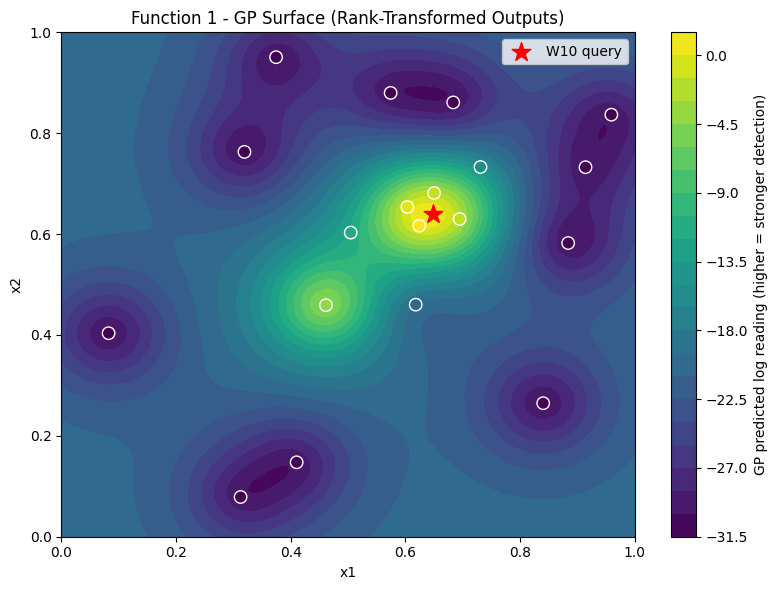

In [17]:
# =============================================================================
# FUNCTION 1 - Radiation Detection (2D)
# changes: 
#    - added new source points to the distance calculation for the length scale
#    - changes acquisition function from UCB to EI to exploit more
# =============================================================================
 
print("=" * 60)
print("Function 1 - Week 10")
print("=" * 60)
 
inputs  = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_1/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_1/initial_outputs.npy')
 
prev_queries = np.array([
    [0.959184, 0.836735],  
    [0.374540, 0.950714],  
    [0.694651, 0.629916],  
    [0.461537, 0.459084],  
    [0.618043, 0.460066], 
    [0.914142, 0.732619],
    [0.504751, 0.602966],
    [0.624182, 0.616547],
    [0.603501, 0.653629],
])
prev_outputs = np.array([
    -5.909566597235814e-107,
    -1.560646704467778e-117,
    -0.0016067678433140744,
    -0.000016877758079573665,
    2.602669489913104e-20,
    -2.694395789176799e-65,
    1.9491751435286236e-12,
    1.3466251251333927,
    0.07758657745022698,
])
 
all_inputs  = np.vstack([inputs, prev_queries])
all_outputs = np.hstack([outputs, prev_outputs])
 
# log-abs transform: measures detection strength on a log scale
# largest absolute value = strongest detection = highest log reading
# 1e-300 prevents log(0) for any exactly-zero readings
log_readings = np.log10(np.abs(all_outputs) + 1e-300)

# find the natural gap between signal and dead zone
# set floor at the midpoint of the largest gap in sorted log readings
sorted_logs = np.sort(log_readings)[::-1]
gaps = sorted_logs[:-1] - sorted_logs[1:]
largest_gap_idx = np.argmax(gaps)
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2

print(f"Largest gap: {sorted_logs[largest_gap_idx]:.1f} to {sorted_logs[largest_gap_idx + 1]:.1f}")
print(f"Floor set at: {floor:.1f}")

# clip: all dead-zone points get the same floor value
ceiling = np.max(np.log10(np.abs(all_outputs) + 1e-300))
log_readings = np.clip(log_readings, floor, ceiling)
 
# identify the strongest detection
best_detection_idx = np.argmax(log_readings)
print(f"Strongest detection: {all_outputs[best_detection_idx]:.6e} at {all_inputs[best_detection_idx]}")
print(f"  log reading: {log_readings[best_detection_idx]:.1f}")
print(f"Log reading range: {log_readings.min():.1f} to {log_readings.max():.1f}")
 
# print all points for verification
print(f"\nAll points (sorted by detection strength):")
sort_idx = np.argsort(log_readings)[::-1]
for i in sort_idx:
    print(f"  {all_inputs[i]} --> output: {all_outputs[i]:.3e} --> log reading: {log_readings[i]:.1f}")

# source-1 points used to to generate the ls estimate
source1_points = np.array([
    [0.624182, 0.616547],  # W8: 1.347
    [0.603501, 0.653629],  # W9: 0.078
    [0.650,    0.682   ],  
])
pairs = [(0,1),(0,2),(1,2)]
dists = [np.linalg.norm(source1_points[i] - source1_points[j]) for i,j in pairs]
ls = np.mean(dists) * 1.5  
print(f"Length scale: {ls:.3f}")

# GP
kernel = Matern(nu=2.5, length_scale=ls, length_scale_bounds="fixed")
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(all_inputs, log_readings)

# EI over candidates
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 2))

mu, sigma = gp.predict(candidates, return_std=True)

# Expected Improvement
best_so_far = log_readings.max()
ei = compute_ei(mu, sigma, best_so_far, xi=0.5)

best_idx = np.argmax(ei)
query = candidates[best_idx]

print(f"\nWeek 10 Query: {format_query(query)}")
print(f"mu (log reading): {mu[best_idx]:.2f}, sigma: {sigma[best_idx]:.2f}, EI: {ei[best_idx]:.4f}")
 
# --- Interpretability: 2D heatmap of GP predicted surface ---
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
 
mu_grid, _ = gp.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)
 
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs[:, 0], all_inputs[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query[0], query[1], marker='*', c='red', s=200, zorder=10, label='W10 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Rank-Transformed Outputs)')
plt.legend()
plt.tight_layout()
plt.show()

# Function 2 - week 10


Function 2 - Week 10
Total points: 19
Current best: 0.685
Feature importances: x1=0.949, x2=0.051

PDP input spans: x1=0.735, x2=0.930
PDP output ranges: x1=0.574, x2=0.017
PDP importances: x1=0.972, x2=0.028
Derived length-scale bounds: x1=(0.0076, 0.756), x2=(0.1000, 10.000)
Initial length scales: x1=0.1470, x2=5.0000
Learned kernel: Matern(length_scale=[0.0763, 10], nu=2.5) + WhiteKernel(noise_level=0.0567)

Week 9 Query: 0.690966-0.996157
  GP mean:   0.629
  GP std:    0.064
  UCB score: 0.693  (kappa=1.0)


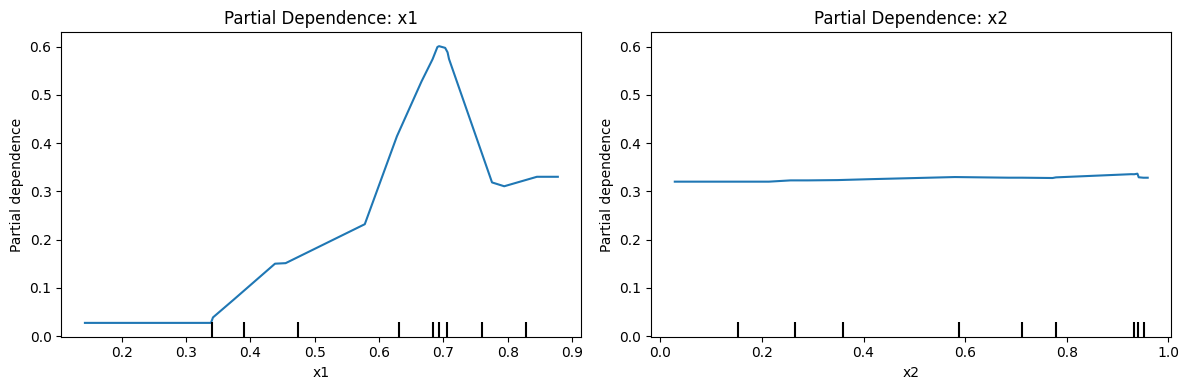

GP residuals at training points (should NOT all be ~0 if WhiteKernel is active):
  max |residual|: 0.0853
  mean |residual|: 0.0311
  std of residuals: 0.0397
  (learned noise_level = 0.0567, implies sigma = 0.2381)


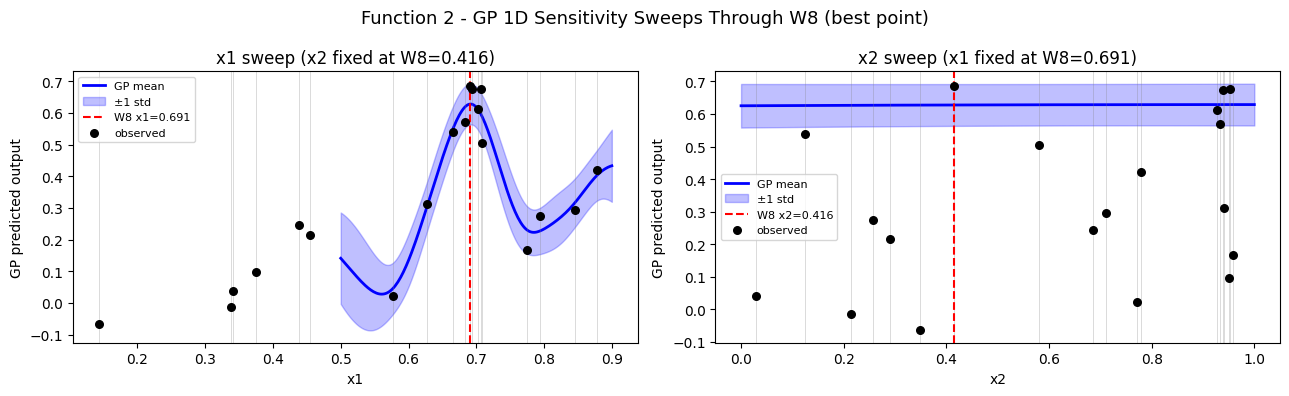

In [18]:
# =============================================================================
# FUNCTION 2 - Noisy Log-Likelihood (2D)
# changes:
#    - removed PDP input-span capping of x2 length scale
#    - use PDP output range to set per-dimension bounds: irrelevant features get large upper bounds
#    - initialise kernel at RF-informed length scales (short for x1, long for x2)
#    - wide bounds let ARD discover relevance; PDP/RF used for validation not constraint
#    - Added per-feature GP sweeps through best point to verify length scales and confirm the GP isn't overfitting
# =============================================================================

print("\n" + "=" * 60)
print("Function 2 - Week 10")
print("=" * 60)

initial_inputs  = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_2/initial_inputs.npy')
initial_outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_2/initial_outputs.npy')

prev_queries = np.array([
    [0.775510, 0.959184],  # W1: 0.166
    [0.683114, 0.932567],  # W2: 0.570
    [0.794441, 0.256481],  # W3: 0.273
    [0.706387, 0.952221],  # W4: 0.675 
    [0.693183, 0.938929],  # W5: 0.674
    [0.374540, 0.950714],  # W6: 0.096 
    [0.627660, 0.941490],  # W7: 0.311 
    [0.690609, 0.415564],  # W8: 0.684 (best)
    [0.708605, 0.579596],  # W9: 0.503
])
prev_outputs = np.array([
    0.16576674, 
    0.56974583, 
    0.27313450, 
    0.67545988, 
    0.67430262, 
    0.09612224849190841, 
    0.3113471043593484,
    0.6848335582399823,
    0.5035276611583426,
])

all_inputs  = np.vstack([initial_inputs, prev_queries])
all_outputs = np.hstack([initial_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}")
print(f"Current best: {all_outputs.max():.3f}")

# RF fitted for PDP computation only -- not used for acquisition
rf = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)
print(f"Feature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}")

# --- PDP-derived length-scale bounds
# compute PDP for each dimension programmatically
pd_x1 = partial_dependence(rf, all_inputs, features=[0], grid_resolution=100)
pd_x2 = partial_dependence(rf, all_inputs, features=[1], grid_resolution=100)

# extract input grid and output values
x1_grid   = pd_x1['grid_values'][0]
x1_pd     = pd_x1['average'][0]
x2_grid   = pd_x2['grid_values'][0]
x2_pd     = pd_x2['average'][0]

x1_input_span  = x1_grid.max() - x1_grid.min()
x2_input_span  = x2_grid.max() - x2_grid.min()
x1_pd_range = x1_pd.max() - x1_pd.min()
x2_pd_range = x2_pd.max() - x2_pd.min()

print(f"\nPDP input spans: x1={x1_input_span:.3f}, x2={x2_input_span:.3f}")
print(f"PDP output ranges: x1={x1_pd_range:.3f}, x2={x2_pd_range:.3f}")

# --- use PDP output range to set per-dimension bounds
#       features with large output variation (important) get tight upper bounds
#       features with small output variation (irrelevant) get large upper bounds
#        so ARD can push irrelevant length scales toward infinity
total_pd_range = x1_pd_range + x2_pd_range + 1e-8
x1_importance  = x1_pd_range / total_pd_range
x2_importance  = x2_pd_range / total_pd_range

# upper bound: input_span for important features
# floor importance at 0.05 to avoid division issues
x1_ls_upper = float(np.clip(x1_input_span / max(x1_importance, 0.05), 0.1, 10.0))
x2_ls_upper = float(np.clip(x2_input_span / max(x2_importance, 0.05), 0.1, 10.0))
x1_ls_lower = x1_ls_upper / 100
x2_ls_lower = x2_ls_upper / 100

print(f"PDP importances: x1={x1_importance:.3f}, x2={x2_importance:.3f}")
print(f"Derived length-scale bounds: x1=({x1_ls_lower:.4f}, {x1_ls_upper:.3f}), x2=({x2_ls_lower:.4f}, {x2_ls_upper:.3f})")

# --- RF-informed initial length scales ---
# important dims start short, less relevant dims start long
# this ensures the optimiser explores the basin ARD should find
x1_ls_init = x1_input_span / 5.0   # short: function varies over this span
x2_ls_init = x2_ls_upper / 2.0     # long: start toward the upper bound

print(f"Initial length scales: x1={x1_ls_init:.4f}, x2={x2_ls_init:.4f}")

# anisotropic GP with PDP-informed bounds and RF-informed initialisation
kernel = (Matern(length_scale=[x1_ls_init, x2_ls_init],
                 length_scale_bounds=[(x1_ls_lower, x1_ls_upper),
                                      (x2_ls_lower, x2_ls_upper)],
                 nu=2.5)
          + WhiteKernel(noise_level=0.01,
                        noise_level_bounds=(1e-6, 1.0)))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp.fit(all_inputs, all_outputs)
print(f"Learned kernel: {gp.kernel_}")

# UCB using GP posterior variance 
np.random.seed(42)
candidates       = np.random.uniform(0, 1, (50000, 2))
gp_mean, gp_std  = gp.predict(candidates, return_std=True)

kappa            = 1.0
ucb_scores       = gp_mean + kappa * gp_std

best_idx = np.argmax(ucb_scores)
query    = candidates[best_idx]

print(f"\nWeek 9 Query: {format_query(query)}")
print(f"  GP mean:   {gp_mean[best_idx]:.3f}")
print(f"  GP std:    {gp_std[best_idx]:.3f}")
print(f"  UCB score: {ucb_scores[best_idx]:.3f}  (kappa={kappa})")

# --- Interpretability: partial dependence plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf, all_inputs, features=[0, 1],
                                         feature_names=['x1', 'x2'], ax=axes)
axes[0].set_title('Partial Dependence: x1')
axes[1].set_title('Partial Dependence: x2')
plt.tight_layout()
plt.show()


# --- Diagnostic: 1D GP sensitivity sweeps through W8 (best point)
#   to test whether the learned length scales reflect real function structure
#   or whether the GP is over-interpolating (length scale too short).

w8_point = np.array([0.690609, 0.415564])  # best point

# --- Check 1: does GP interpolate through training points? ---
train_preds = gp.predict(all_inputs)
train_residuals = all_outputs - train_preds
print("GP residuals at training points (should NOT all be ~0 if WhiteKernel is active):")
print(f"  max |residual|: {np.abs(train_residuals).max():.4f}")
print(f"  mean |residual|: {np.abs(train_residuals).mean():.4f}")
print(f"  std of residuals: {train_residuals.std():.4f}")
print(f"  (learned noise_level = {gp.kernel_.k2.noise_level:.4f}, "
      f"implies sigma = {gp.kernel_.k2.noise_level**0.5:.4f})")

# --- Check 2: x1 sweep, x2 fixed at W8 ---
x1_sweep = np.linspace(0.50, 0.90, 200)
x1_test  = np.column_stack([x1_sweep, np.full(200, w8_point[1])])
x1_mu, x1_std = gp.predict(x1_test, return_std=True)

# --- Check 3: x2 sweep, x1 fixed at W8 ---
x2_sweep = np.linspace(0.0, 1.0, 200)
x2_test  = np.column_stack([np.full(200, w8_point[0]), x2_sweep])
x2_mu, x2_std = gp.predict(x2_test, return_std=True)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# x1 sweep
ax = axes[0]
ax.plot(x1_sweep, x1_mu, 'b-', lw=2, label='GP mean')
ax.fill_between(x1_sweep,
                x1_mu - x1_std,
                x1_mu + x1_std,
                alpha=0.25, color='blue', label='±1 std')
# mark observed points projected onto this slice
for pt, out in zip(all_inputs, all_outputs):
    ax.axvline(pt[0], color='grey', lw=0.5, alpha=0.4)
ax.axvline(w8_point[0], color='red', lw=1.5, linestyle='--', label=f'W8 x1={w8_point[0]:.3f}')
ax.scatter(all_inputs[:, 0], all_outputs, c='black', s=30, zorder=5, label='observed')
ax.set_xlabel('x1')
ax.set_ylabel('GP predicted output')
ax.set_title('x1 sweep (x2 fixed at W8=0.416)')
ax.legend(fontsize=8)

# x2 sweep
ax = axes[1]
ax.plot(x2_sweep, x2_mu, 'b-', lw=2, label='GP mean')
ax.fill_between(x2_sweep,
                x2_mu - x2_std,
                x2_mu + x2_std,
                alpha=0.25, color='blue', label='±1 std')
for pt, out in zip(all_inputs, all_outputs):
    ax.axvline(pt[1], color='grey', lw=0.5, alpha=0.4)
ax.axvline(w8_point[1], color='red', lw=1.5, linestyle='--', label=f'W8 x2={w8_point[1]:.3f}')
ax.scatter(all_inputs[:, 1], all_outputs, c='black', s=30, zorder=5, label='observed')
ax.set_xlabel('x2')
ax.set_ylabel('GP predicted output')
ax.set_title('x2 sweep (x1 fixed at W8=0.691)')
ax.legend(fontsize=8)

plt.suptitle('Function 2 - GP 1D Sensitivity Sweeps Through W8 (best point)', fontsize=13)
plt.tight_layout()
plt.show()

# Function 3 - week 10


Function 3 - Week 10
Total points: 24, best: -0.0000607

RF feature importances:
  A     : 0.1009
  B     : 0.0927
  C     : 0.1838
  A*B   : 0.0588
  A*C   : 0.0755
  B*C   : 0.1168
  A^2   : 0.0878
  B^2   : 0.1278
  C^2   : 0.1559

RF train R² (original space): 0.4880
RF train predictions vs actual:
  predicted: -0.088036, actual: -0.112122
  predicted: -0.075841, actual: -0.087963
  predicted: -0.073397, actual: -0.111415
  predicted: -0.023825, actual: -0.034835
  predicted: -0.056232, actual: -0.048008
  predicted: -0.054154, actual: -0.110621
  predicted: -0.146817, actual: -0.398926
  predicted: -0.086112, actual: -0.113869
  predicted: -0.081603, actual: -0.131461
  predicted: -0.080778, actual: -0.094190
  predicted: -0.057170, actual: -0.046947
  predicted: -0.057160, actual: -0.105965
  predicted: -0.106379, actual: -0.118048
  predicted: -0.056191, actual: -0.036378
  predicted: -0.040382, actual: -0.056758
  predicted: -0.023636, actual: -0.029062
  predicted: -0.050251,

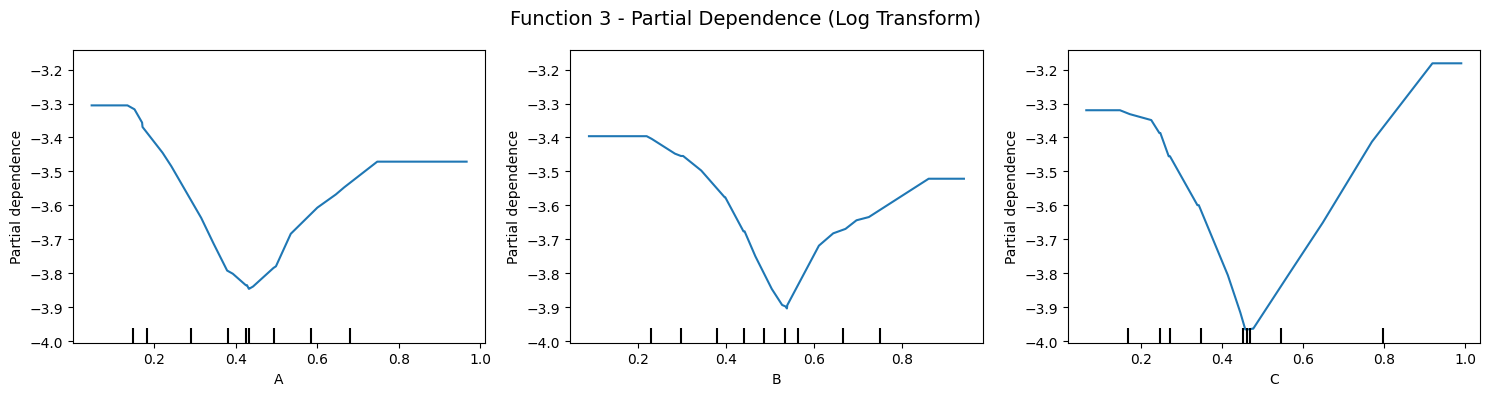

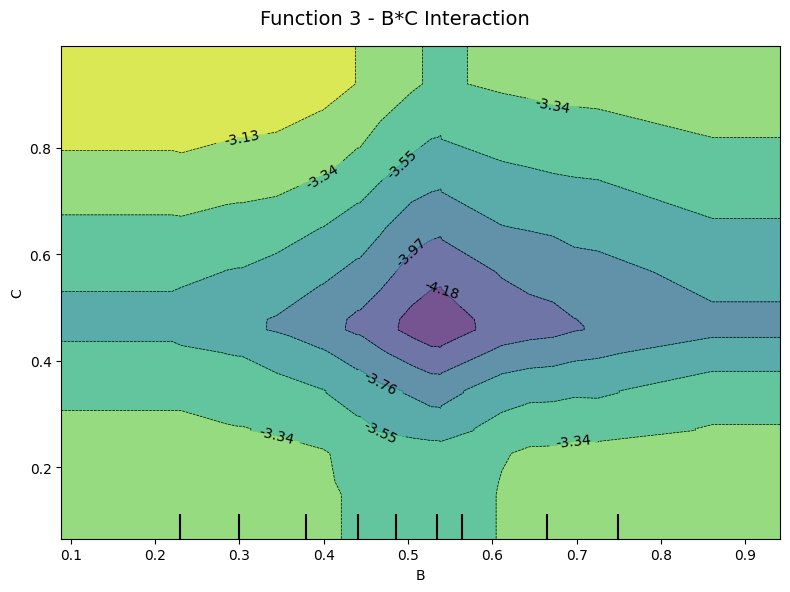

Top 5 points (closest to zero):
  1: index 20, Y = -0.0000607
  2: index 19, Y = -0.0006169
  3: index 17, Y = -0.0006328
  4: index 23, Y = -0.0016488
  5: index 18, Y = -0.0029447

Transform: none
  Overall MAE: 0.037518
  Top-5 MAE:   0.023211
  Top-5 rank overlap: 4/5
  Top-5 detail:
    idx 20: actual -0.0000607 -> pred -0.0174281 (err 0.0173674)
    idx 19: actual -0.0006169 -> pred -0.0189096 (err 0.0182926)
    idx 17: actual -0.0006328 -> pred -0.0309837 (err 0.0303509)
    idx 23: actual -0.0016488 -> pred -0.0173339 (err 0.0156851)
    idx 18: actual -0.0029447 -> pred -0.0373030 (err 0.0343583)

Transform: sqrt
  Overall MAE: 0.035782
  Top-5 MAE:   0.010578
  Top-5 rank overlap: 4/5
  Top-5 detail:
    idx 20: actual -0.0000607 -> pred -0.0080048 (err 0.0079441)
    idx 19: actual -0.0006169 -> pred -0.0077837 (err 0.0071667)
    idx 17: actual -0.0006328 -> pred -0.0172651 (err 0.0166323)
    idx 23: actual -0.0016488 -> pred -0.0070120 (err 0.0053632)
    idx 18: actual 

In [19]:
# =============================================================================
# FUNCTION 3 - Drug Discovery (3D)
# changes:
#   - Log transform on outputs: fixes surrogate underestimation in near-zero region (LOO CV: Top-5 MAE from 0.0232 to 0.0024)
#   - kappa lowered to from 0.5 to 0.3
#   - n_estimators reverted to 200: keeps ensemble variance expressive for uncertainty estimates
#   - argmax replaced with LCB using ensemble mean and std from ExtraTrees
#   - exclusion filter tightened: now within min_distance = 0.001
#   - updated PDP plots to show log-transform
# =============================================================================

print("\n" + "=" * 60)
print("Function 3 - Week 10")
print("=" * 60)

f3_inputs  = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_3/initial_inputs.npy')
f3_outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_3/initial_outputs.npy')

prev_queries = np.array([
    [0.378956, 0.302768, 0.459346],  # W1: -0.0291
    [0.315339, 0.088659, 0.415174],  # W2: -0.0623
    [0.392735, 0.504381, 0.464332],  # W3: -0.000633
    [0.498607, 0.467046, 0.477827],  # W4: -0.00294
    [0.432840, 0.535542, 0.476983],  # W5: -0.000617
    [0.442511, 0.539648, 0.462840],  # W6: -0.0000607 (best)
    [0.427601, 0.442546, 0.649322],  # W7: -0.0906
    [0.432117, 0.538819, 0.446114],  # W8: -0.00432
    [0.425043, 0.527911, 0.464138],  # W9: -0.00165
])
prev_outputs = np.array([
    -0.02906213067759293,
    -0.06230989251412482,
    -0.0006328364393800658,
    -0.0029446702316140265,
    -0.0006169444563794807,
    -0.00006071018004296725,
    -0.09063996317418548,
    -0.004316355713810623,
    -0.001648812524906173,
])

X = np.vstack([f3_inputs, prev_queries])
Y = np.hstack([f3_outputs, prev_outputs])

print(f"Total points: {len(Y)}, best: {Y.max():.7f}")

# --- Log transform ---
eps = 1e-10
Y_log = np.log(-Y + eps)

# --- Polynomial features ---
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

# --- ExtraTrees on polynomial features (log-transformed outputs) ---
rf = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf.fit(X_poly, Y_log)

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")

# Train predictions (inverted back to original space)
train_preds_log = rf.predict(X_poly)
train_preds = -(np.exp(train_preds_log) - eps)
print(f"\nRF train R2 (original space): {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")

# --- Candidate search ---
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 3))
cand_poly  = poly.transform(candidates)

# --- Prevent resubmitting near-identical points (tight radius)
min_distance = 0.001
distances = np.min(np.linalg.norm(candidates[:, None, :] - X[None, :, :], axis=2), axis=1)
mask = distances > min_distance
candidates = candidates[mask]
cand_poly = poly.transform(candidates)

# --- Ensemble uncertainty in log space ---
tree_preds = np.array([tree.predict(cand_poly) for tree in rf.estimators_])
mean_preds = tree_preds.mean(axis=0)
std_preds  = tree_preds.std(axis=0)

# --- LCB acquisition in log space ---
# in log space: lower values = closer to zero in original space = better
# minimise in log space: acquisition = mean - kappa * std
kappa = 0.3
acquisition = mean_preds - kappa * std_preds
best_idx    = np.argmin(acquisition)
query       = candidates[best_idx]

# --- Top 10 candidates ---
top_n = 10
top_indices = np.argsort(acquisition)[:top_n]
print(f"\nTop {top_n} candidates (LCB, kappa={kappa}, log space):")
for i, idx in enumerate(top_indices):
    pred_original = -(np.exp(mean_preds[idx]) - eps)
    print(f"  {i+1}: {format_query(candidates[idx])}, "
          f"mean(log): {mean_preds[idx]:.4f}, std(log): {std_preds[idx]:.4f}, "
          f"acq: {acquisition[idx]:.4f}, pred(original): {pred_original:.6f}")

print(f"\nWeek 10 Query: {format_query(query)}")
pred_original = -(np.exp(mean_preds[best_idx]) - eps)
print(f"Predicted (original space): {pred_original:.6f}")

# --- Interpretability Plots ---
rf_raw = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence (Log Transform)', fontsize=14)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[(1, 2)],
                                         feature_names=['A', 'B', 'C'], ax=[ax2])
plt.suptitle('Function 3 - B*C Interaction', fontsize=14)
plt.tight_layout()
plt.show()


# --- LOO Cross-Validation Diagnostic: no transform vs sqrt vs log
n = len(Y)
eps = 1e-10

# Identify top-5 points by actual output (closest to zero)
top5_indices = np.argsort(Y)[::-1][:5]
print("Top 5 points (closest to zero):")
for i, idx in enumerate(top5_indices):
    print(f"  {i+1}: index {idx}, Y = {Y[idx]:.7f}")

transforms = [
    ("none",  lambda y: y,                lambda p: p),
    ("sqrt",  lambda y: -np.sqrt(-y),     lambda p: -(p**2)),
    ("log",   lambda y: np.log(-y + eps), lambda p: -(np.exp(p) - eps)),
]

for t_name, forward, inverse in transforms:
    Y_t = forward(Y)
    preds_original = np.zeros(n)

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        Y_train = np.delete(Y_t, i, axis=0)
        X_test  = X[i:i+1]

        poly_cv = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly_cv.fit_transform(X_train)
        X_test_poly  = poly_cv.transform(X_test)

        rf_cv = ExtraTreesRegressor(
            n_estimators=200, max_features='sqrt',
            min_samples_leaf=2, random_state=42
        )
        rf_cv.fit(X_train_poly, Y_train)

        pred_t = rf_cv.predict(X_test_poly)[0]
        preds_original[i] = inverse(pred_t)

    mae = mean_absolute_error(Y, preds_original)
    top5_mae = mean_absolute_error(Y[top5_indices], preds_original[top5_indices])
    pred_top5 = np.argsort(preds_original)[::-1][:5]
    rank_overlap = len(set(top5_indices) & set(pred_top5))

    print(f"\nTransform: {t_name}")
    print(f"  Overall MAE: {mae:.6f}")
    print(f"  Top-5 MAE:   {top5_mae:.6f}")
    print(f"  Top-5 rank overlap: {rank_overlap}/5")
    print(f"  Top-5 detail:")
    for idx in top5_indices:
        print(f"    idx {idx:2d}: actual {Y[idx]:.7f} -> pred {preds_original[idx]:.7f} (err {abs(Y[idx]-preds_original[idx]):.7f})")


# Function 4 - week 10


Function 4 - Week 10
Total points: 39, best: 0.6309

Candidates: 5000 W2 + 3000 W9 + 2000 global = 10000 total
Fitted kernel: 0.834**2 * Matern(length_scale=0.4, nu=2.5)
Log-marginal-likelihood: -22.5563

Week 10 Query: 0.386937-0.394308-0.366806-0.377180
mean: 1.043
std:  0.476
EI:   0.454711
W2 point:  mean=0.588  std=0.089
W10 query: mean=1.043  std=0.476


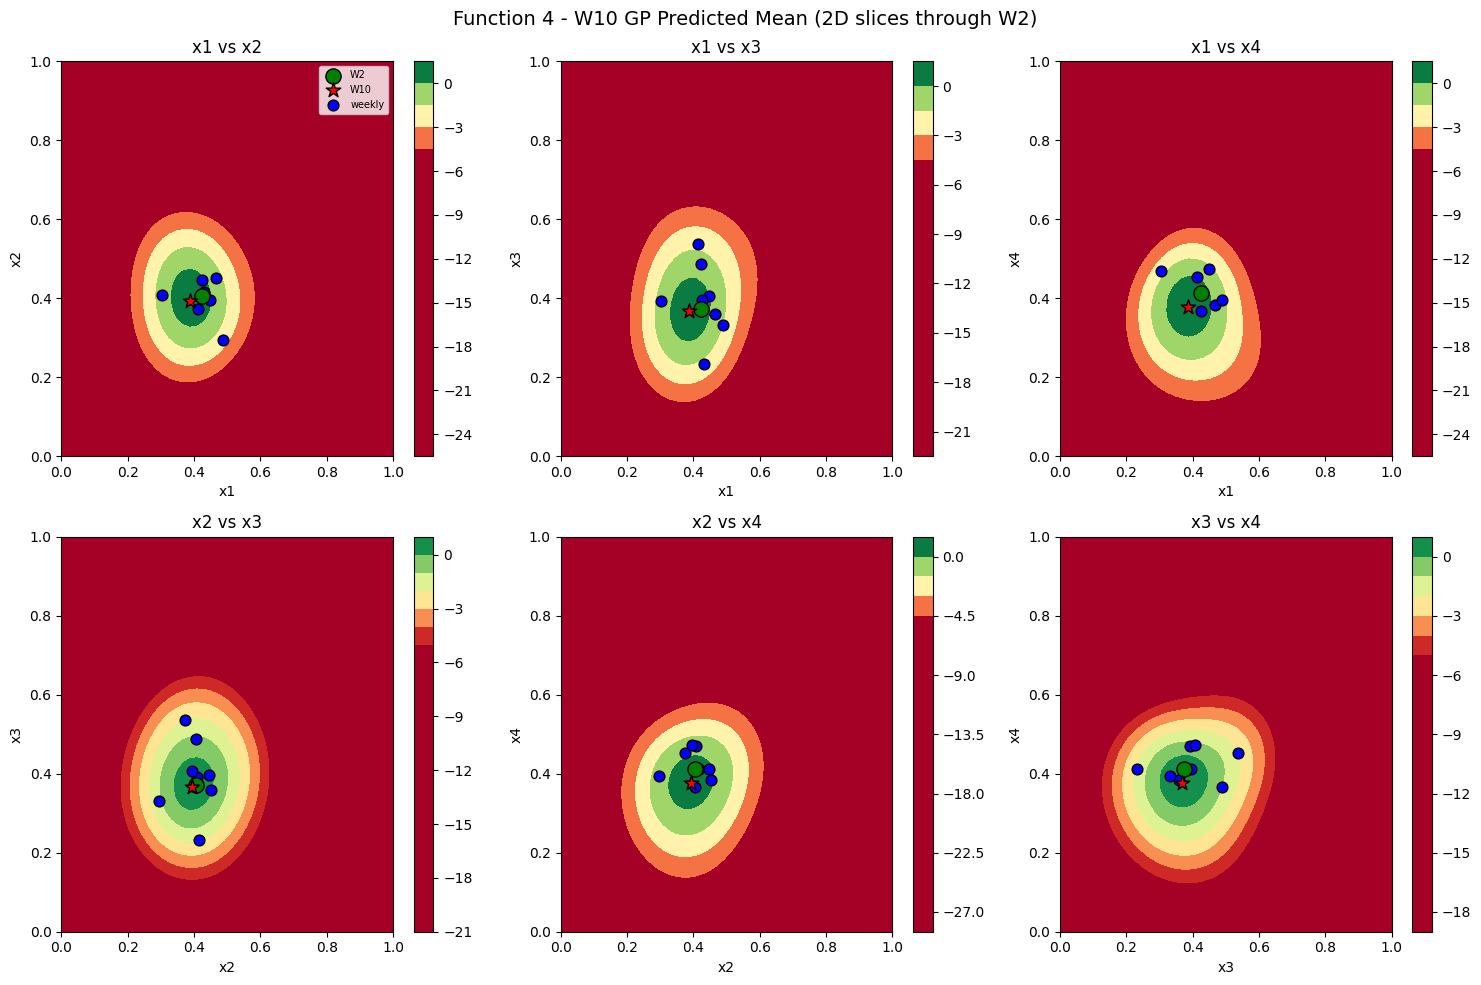

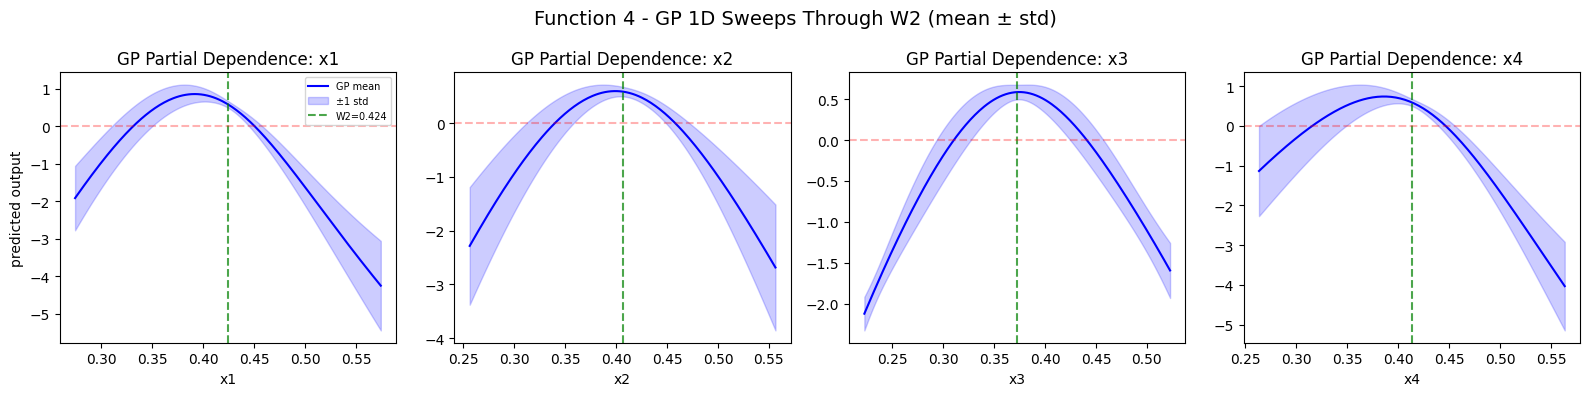

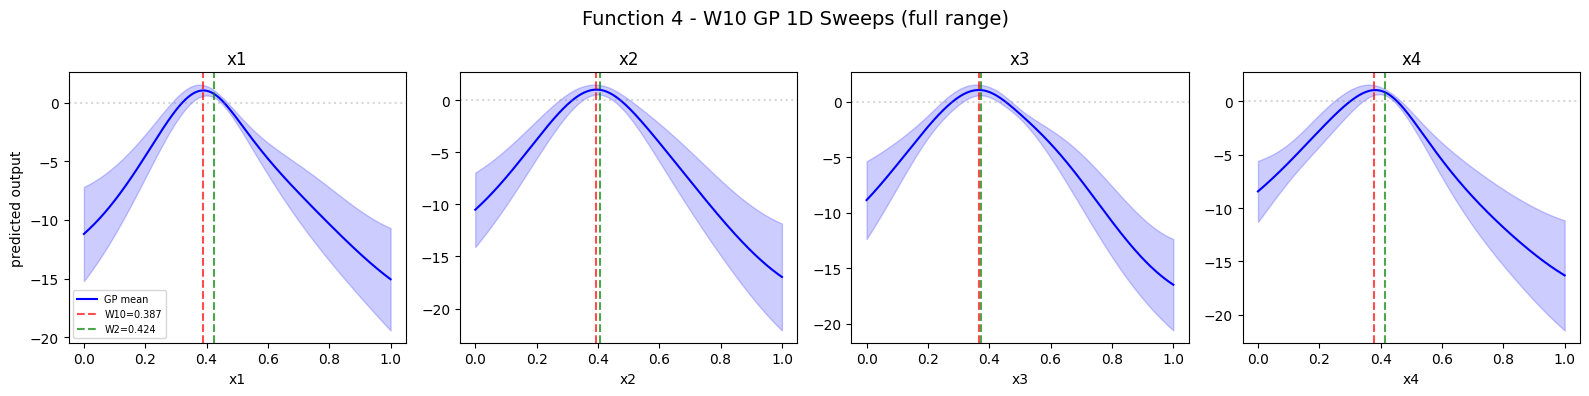

In [20]:
# =============================================================================
# FUNCTION 4 - Warehouse Placement (4D)
# changes:
#   - GP hyperparams tuned via LOO CV (48 configs) + fixed length-scale sweep
#   - ARD length scale changed to isotropic (ARD overfits with 39 points)
#   - fixed ls=0.4, alpha=1e-4 (resolves W2 peak; free ls jumps between 0.05/1.5+)
#   - acquisition function from UCB to EI (xi=0.01) for late-stage exploitation
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 4 - Week 10")
print("=" * 60)
 
f4_inputs  = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_4/initial_inputs.npy')
f4_outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_4/initial_outputs.npy')
 
prev_queries = np.array([
    [0.466173, 0.451984, 0.359193, 0.383111],  # W1: -0.965
    [0.424201, 0.406375, 0.372722, 0.413313],  # W2: +0.631 (best)
    [0.413541, 0.373697, 0.536536, 0.453354],  # W3: -2.150
    [0.424125, 0.404716, 0.487507, 0.367688],  # W4: -0.992
    [0.488793, 0.294975, 0.332280, 0.395576],  # W5: -2.463
    [0.303872, 0.408521, 0.392275, 0.469543],  # W6: -2.141
    [0.447976, 0.395249, 0.406174, 0.473345],  # W7: -1.249
    [0.431511, 0.415976, 0.232614, 0.411417],  # W8: -1.993
    [0.425192, 0.446783, 0.395943, 0.413089],  # W9: 0.1866
])
prev_outputs = np.array([
    -0.9654345395220925, 
    0.6308582112564989, 
    -2.1500998298742817,
    -0.9915950770116662, 
    -2.4630197287139697, 
    -2.1414388028868454,
    -1.2497635252595596,
    -1.9932051275194236,
    0.1866021739608965,
])
 
f4_all_inputs  = np.vstack([f4_inputs, prev_queries])
f4_all_outputs = np.hstack([f4_outputs, prev_outputs])
print(f"Total points: {len(f4_all_outputs)}, best: {f4_all_outputs.max():.4f}")

# --- Candidate generation
np.random.seed(42)

week2_query = np.array([0.424201, 0.406375, 0.372722, 0.413313])
week9_query = np.array([0.425192, 0.446783, 0.395943, 0.413089])  

candidates_w2 = np.array([np.clip(week2_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(5000)])
candidates_w9 = np.array([np.clip(week9_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(3000)])
candidates_global = np.random.uniform(0, 1, size=(2000, 4))

candidates = np.vstack([candidates_w2, candidates_w9, candidates_global])
print(f"\nCandidates: {len(candidates_w2)} W2 + {len(candidates_w9)} W9 + {len(candidates_global)} global = {len(candidates)} total")

# --- GP surrogate
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.4,
    length_scale_bounds='fixed',
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-4, normalize_y=True)
gp.fit(f4_all_inputs, f4_all_outputs)

print(f"Fitted kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.4f}")

# --- EI acquisition (switch from UCB: late-stage)
mu, sigma = gp.predict(candidates, return_std=True)

xi = 0.01
best_f = f4_all_outputs.max()
improvement = mu - best_f - xi
Z = np.where(sigma > 1e-10, improvement / sigma, 0.0)
ei = np.where(sigma > 1e-10,
              improvement * norm.cdf(Z) + sigma * norm.pdf(Z),
              0.0)

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 10 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f}")
print(f"std:  {sigma[best_index]:.3f}")
print(f"EI:   {ei[best_index]:.6f}")

w2_mu, w2_std = gp.predict(week2_query.reshape(1, -1), return_std=True)
q_mu, q_std = gp.predict(query.reshape(1, -1), return_std=True)
print(f"W2 point:  mean={w2_mu[0]:.3f}  std={w2_std[0]:.3f}")
print(f"W10 query: mean={q_mu[0]:.3f}  std={q_std[0]:.3f}")
 
# --- Interpretability plots ---
# 2D GP predicted mean -- sweep pairs of dimensions through W2
dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week2_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    ax.scatter(week2_query[d1], week2_query[d2], c='green', edgecolors='black', s=120, zorder=5, label='W2')
    ax.scatter(query[d1], query[d2], c='red', edgecolors='black', s=120, zorder=5, marker='*', label='W10')
    ax.scatter(prev_queries[:, d1], prev_queries[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W10 GP Predicted Mean (2D slices through W2)', fontsize=14)
plt.tight_layout()
plt.show()

# RF 1D partial dependence through W2 -- shows basin shape per dimension
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week2_query[i] - 0.15, week2_query[i] + 0.15, 200)    
    test_points = np.tile(week2_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week2_query[i], color='green', linestyle='--', alpha=0.7, label=f'W2={week2_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W2 (mean ± std)', fontsize=14)
plt.tight_layout()
plt.show()

# 1D sweeps with W10 GP
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dim_names = ['x1', 'x2', 'x3', 'x4']

for i, ax in enumerate(axes):
    sweep = np.linspace(0.0, 1.0, 300)
    test_points = np.tile(query, (300, 1))  # sweep through the W10 query point
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue')
    ax.axvline(x=query[i], color='red', linestyle='--', alpha=0.7, label=f'W10={query[i]:.3f}')
    ax.axvline(x=week2_query[i], color='green', linestyle='--', alpha=0.7, label=f'W2={week2_query[i]:.3f}')
    ax.axhline(y=0, color='grey', linestyle=':', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'{dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W10 GP 1D Sweeps (full range)', fontsize=14)
plt.tight_layout()
plt.show()


# mu, sigma = gp.predict(candidates, return_std=True)
# best_f = f4_all_outputs.max()

# for xi in [0.0, 0.01, 0.05, 0.1, 0.5]:
#     ei = compute_ei(mu, sigma, best_f, xi=xi)
#     idx = np.argmax(ei)
#     print(f"xi={xi:<6} query={format_query(candidates[idx])}  mean={mu[idx]:.3f}  std={sigma[idx]:.3f}  EI={ei[idx]:.6f}")


# from sklearn.gaussian_process.kernels import ConstantKernel, Matern

# # Test fixed length-scales with nu=2.5
# # Fix length_scale by setting bounds to (val-eps, val+eps)
# loo = LeaveOneOut()

# print(f"{'fixed_ls':<12} {'alpha':<12} {'LOO R2':<12} {'LOO MSE':<12} {'LML':<12}")
# print("-" * 60)

# for ls in [0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.80, 1.00]:
#     for alpha in [1e-4, 1e-3, 0.005, 0.01]:
#         kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#             length_scale=ls,
#             length_scale_bounds='fixed',
#             nu=2.5
#         )
        
#         loo_preds = np.zeros(len(f4_all_outputs))
#         failed = False
#         for train_idx, test_idx in loo.split(f4_all_inputs):
#             try:
#                 gp_loo = GaussianProcessRegressor(
#                     kernel=kern.clone_with_theta(kern.theta),
#                     n_restarts_optimizer=10, alpha=alpha, normalize_y=True)
#                 gp_loo.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
#                 loo_preds[test_idx] = gp_loo.predict(f4_all_inputs[test_idx])
#             except:
#                 failed = True
#                 break
        
#         if failed:
#             continue
        
#         r2 = r2_score(f4_all_outputs, loo_preds)
#         mse = mean_squared_error(f4_all_outputs, loo_preds)
        
#         # Fit on full data for LML
#         gp_full = GaussianProcessRegressor(
#             kernel=kern.clone_with_theta(kern.theta),
#             n_restarts_optimizer=10, alpha=alpha, normalize_y=True)
#         gp_full.fit(f4_all_inputs, f4_all_outputs)
#         lml = gp_full.log_marginal_likelihood_value_
        
#         print(f"{ls:<12} {alpha:<12} {r2:<12.4f} {mse:<12.4f} {lml:<12.4f}")


# # Compare how each config sees W2
# configs = [
#     ('ls=0.8 a=0.001', 0.8, 0.001),
#     ('ls=0.8 a=0.005', 0.8, 0.005),
#     ('ls=1.0 a=0.001', 1.0, 0.001),
#     ('ls=1.0 a=0.005', 1.0, 0.005),
#     ('unfixed a=0.005', None, 0.005),  # the previous W10 config for comparison
# ]

# week2_query = np.array([0.424201, 0.406375, 0.372722, 0.413313])

# for name, ls, alpha in configs:
#     if ls is None:
#         kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#             length_scale=0.3, length_scale_bounds=(0.01, 5.0), nu=2.5)
#     else:
#         kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#             length_scale=ls, length_scale_bounds='fixed', nu=2.5)
    
#     gp_test = GaussianProcessRegressor(
#         kernel=kern, n_restarts_optimizer=20, alpha=alpha, normalize_y=True)
#     gp_test.fit(f4_all_inputs, f4_all_outputs)
    
#     w2_mu, w2_std = gp_test.predict(week2_query.reshape(1, -1), return_std=True)
#     print(f"{name:<22} W2 pred: mean={w2_mu[0]:.3f}  std={w2_std[0]:.3f}  (actual: 0.631)")


# configs = [
#     ('ls=0.4 a=1e-4', 0.4, 1e-4),
#     ('ls=0.4 a=1e-3', 0.4, 1e-3),
#     ('ls=0.5 a=1e-4', 0.5, 1e-4),
#     ('ls=0.5 a=1e-3', 0.5, 1e-3),
#     ('ls=0.6 a=1e-4', 0.6, 1e-4),
#     ('ls=0.6 a=1e-3', 0.6, 1e-3),
#     ('ls=0.8 a=1e-3', 0.8, 1e-3),
# ]

# for name, ls, alpha in configs:
#     kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#         length_scale=ls, length_scale_bounds='fixed', nu=2.5)
#     gp_test = GaussianProcessRegressor(
#         kernel=kern, n_restarts_optimizer=20, alpha=alpha, normalize_y=True)
#     gp_test.fit(f4_all_inputs, f4_all_outputs)
    
#     w2_mu, w2_std = gp_test.predict(week2_query.reshape(1, -1), return_std=True)
#     print(f"\n{name:<22} W2 pred: mean={w2_mu[0]:.3f}  std={w2_std[0]:.3f}")

# print(f"{'alpha':<12} {'fitted_ls':<12} {'LML':<12}")
# print("-" * 36)
# for a in [1e-6, 1e-5, 1e-4, 1e-3, 5e-3, 0.01]:
#     kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#         length_scale=0.3, length_scale_bounds=(0.01, 5.0), nu=1.5)
#     gp_test = GaussianProcessRegressor(
#         kernel=kern, n_restarts_optimizer=20, alpha=a, normalize_y=True)
#     gp_test.fit(f4_all_inputs, f4_all_outputs)
#     ls = gp_test.kernel_.k2.length_scale
#     lml = gp_test.log_marginal_likelihood_value_
#     print(f"{a:<12} {ls:<12.4f} {lml:<12.4f}")


# print(f"{'alpha':<12} {'fitted_ls':<12} {'LML':<12}")
# print("-" * 36)
# for a in [1e-6, 1e-5, 1e-4, 1e-3, 5e-3, 0.01]:
#     kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#         length_scale=0.3, length_scale_bounds=(0.01, 5.0), nu=2.5)
#     gp_test = GaussianProcessRegressor(
#         kernel=kern, n_restarts_optimizer=20, alpha=a, normalize_y=True)
#     gp_test.fit(f4_all_inputs, f4_all_outputs)
#     ls = gp_test.kernel_.k2.length_scale
#     lml = gp_test.log_marginal_likelihood_value_
#     print(f"{a:<12} {ls:<12.4f} {lml:<12.4f}")


# configs = [
#     ('nu=1.5 a=1e-6', 1.5, 1e-6),
#     ('nu=2.5 a=0.005', 2.5, 0.005),
#     ('nu=2.5 a=1e-6', 2.5, 1e-6),
# ]

# loo = LeaveOneOut()
# for name, nu, alpha in configs:
#     kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#         length_scale=0.3, length_scale_bounds=(0.01, 5.0), nu=nu)
    
#     loo_preds = np.zeros(len(f4_all_outputs))
#     for train_idx, test_idx in loo.split(f4_all_inputs):
#         gp_loo = GaussianProcessRegressor(
#             kernel=kern.clone_with_theta(kern.theta),
#             n_restarts_optimizer=10, alpha=alpha, normalize_y=True)
#         gp_loo.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
#         loo_preds[test_idx] = gp_loo.predict(f4_all_inputs[test_idx])
    
#     r2 = r2_score(f4_all_outputs, loo_preds)
#     mse = mean_squared_error(f4_all_outputs, loo_preds)
#     print(f"{name:<20} LOO R2={r2:.4f}  MSE={mse:.4f}")



# --- Diagnostics
# loo = LeaveOneOut()

# surrogates = {
#     # GP variants with the best alpha/nu from before
#     'GP Matern2.5 iso (ls_lb=0.01)': lambda: GaussianProcessRegressor(
#         kernel=ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#             length_scale=0.3, length_scale_bounds=(0.01, 5.0), nu=2.5),
#         n_restarts_optimizer=10, alpha=1e-6, normalize_y=True),
    
#     'GP Matern1.5 iso (ls_lb=0.01)': lambda: GaussianProcessRegressor(
#         kernel=ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#             length_scale=0.3, length_scale_bounds=(0.01, 5.0), nu=1.5),
#         n_restarts_optimizer=10, alpha=1e-6, normalize_y=True),
    
#     'GP RBF iso': lambda: GaussianProcessRegressor(
#         kernel=ConstantKernel(1.0, (1e-3, 1e3)) * RBF(
#             length_scale=0.3, length_scale_bounds=(0.01, 5.0)),
#         n_restarts_optimizer=10, alpha=1e-6, normalize_y=True),
    
#     'GP RatQuad': lambda: GaussianProcessRegressor(
#         kernel=ConstantKernel(1.0, (1e-3, 1e3)) * RationalQuadratic(
#             length_scale=0.3, alpha=1.0,
#             length_scale_bounds=(0.01, 5.0), alpha_bounds=(0.01, 100)),
#         n_restarts_optimizer=10, alpha=1e-6, normalize_y=True),

#     # Tree-based
#     'RF 500': lambda: RandomForestRegressor(n_estimators=500, random_state=42),
#     'RF 1000 maxdepth5': lambda: RandomForestRegressor(
#         n_estimators=1000, max_depth=5, random_state=42),
#     'GradBoost 500': lambda: GradientBoostingRegressor(
#         n_estimators=500, max_depth=3, learning_rate=0.05, random_state=42),
#     'GradBoost 200 d2': lambda: GradientBoostingRegressor(
#         n_estimators=200, max_depth=2, learning_rate=0.1, random_state=42),

#     # KNN (simple baseline)
#     'KNN k=3': lambda: KNeighborsRegressor(n_neighbors=3),
#     'KNN k=5': lambda: KNeighborsRegressor(n_neighbors=5),
# }

# print(f"Running LOO CV over {len(surrogates)} surrogates on {len(f4_all_outputs)} points\n")

# start = time.time()
# results = []

# for name, model_fn in surrogates.items():
#     loo_preds = np.zeros(len(f4_all_outputs))
#     failed = False
    
#     for train_idx, test_idx in loo.split(f4_all_inputs):
#         try:
#             model = model_fn()
#             model.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
#             loo_preds[test_idx] = model.predict(f4_all_inputs[test_idx])
#         except Exception as e:
#             failed = True
#             break
    
#     if failed:
#         print(f"  {name}: FAILED")
#         continue
    
#     r2 = r2_score(f4_all_outputs, loo_preds)
#     mse = mean_squared_error(f4_all_outputs, loo_preds)
#     results.append({'name': name, 'r2': r2, 'mse': mse})

# elapsed = time.time() - start
# print(f"Completed in {elapsed:.1f}s\n")

# results.sort(key=lambda x: x['r2'], reverse=True)

# print(f"{'Rank':<5} {'Surrogate':<32} {'LOO R2':<10} {'LOO MSE':<10}")
# print("-" * 60)
# for i, r in enumerate(results):
#     marker = " <--" if i == 0 else ""
#     print(f"{i+1:<5} {r['name']:<32} {r['r2']:<10.4f} {r['mse']:<10.4f}{marker}")

# print(f"Output std: {f4_all_outputs.std():.2f}")
# print(f"Output range: [{f4_all_outputs.min():.2f}, {f4_all_outputs.max():.2f}]")


# Function 5 - week 10


Function 5 - Week 10
Total points: 29, best so far: 8343.75
Above-bounds candidates passed to GP: 9476
In-bounds candidates passed to GP: 524

Week 10 Query:       1.186309-1.147512-1.074804-1.174751
GP predicted yield: 19167.86
GP std (log scale): 1.1623
SVR prediction:     9679.77

--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         2201.8     2201.8     2223.8
W2         2381.5     2381.5     2377.5
W3         2689.2     2689.2     2666.7
W4         3223.2     3223.2     3245.0
W5         3287.0     3287.0     3264.5
W6         4354.1     4354.1     4332.8
W7         5255.7     5255.7     5232.9
W8         6014.3     6014.3     6035.8
W9         8343.7     8343.7     8322.5

--- GP extrapolation beyond 1.0 ---
    x1   GP yield     GP std
  0.95     7857.2     0.0263
  1.00     8592.6     0.0197
  1.05     9279.7     0.1001
  1.10     9847.1     0.2111
  1.20    10415.0     0.5054
  1.30    10106.6     0.8625
  1.50     7647.0     1.6328


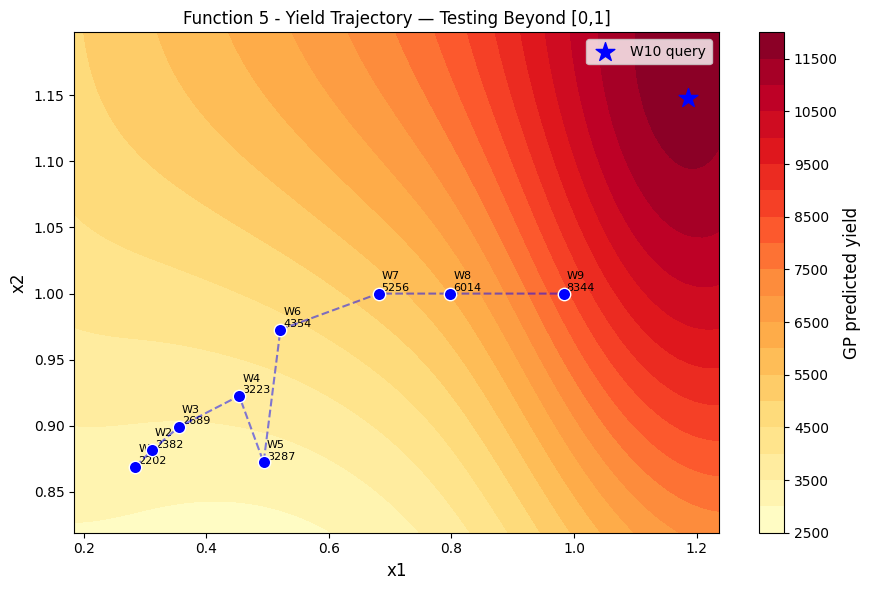

In [22]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
#   Testing whether input space extends beyond [0,1].
#   All 4 dims converged to boundary with accelerating gains over 8 weeks.
# changes:
#   - Removed x3/x4 pinning — let GP decide all dimensions freely
#   - Expanded candidate bounds from [0,1] to [0,2.0]
#   - SVR pre-filter bypassed for above [0,1] bounds candidates
#   - Switched acquisition from EI to GP mean (greedy) 
#      EI was dominated by the best [0.98,0.99,0.99,0.99] point and couldn't select exploration candidates
#   - Fixed format_query clipping bug (was hiding values above 0.999999)
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 5 - Week 10")
print("=" * 60)
 
f5_inputs  = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_5/initial_inputs.npy')
f5_outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_5/initial_outputs.npy')

prev_queries = np.array([
    [0.284290, 0.869208, 0.999999, 0.903273],  # W1: 2201.83
    [0.311208, 0.881577, 0.999999, 0.915050],  # W2: 2381.54
    [0.355085, 0.899160, 0.999900, 0.934196],  # W3: 2689.15
    [0.453609, 0.922659, 0.999999, 0.960267],  # W4: 3223.24
    [0.493503, 0.872392, 0.999999, 0.999999],  # W5: 3286.99
    [0.520874, 0.972838, 0.999999, 0.999999],  # W6: 4354.08
    [0.681041, 0.999999, 0.999999, 0.999999],  # W7: 5255.70
    [0.798393, 0.999999, 0.999999, 0.999999],  # W8: 6014.32
    [0.982974, 0.999999, 0.999999, 0.999999],  # W9: 8343.74
])
prev_outputs = np.array([
    2201.834589108927, 
    2381.536867607932, 
    2689.1537294933396,
    3223.2410694936825, 
    3286.9929500236235, 
    4354.076520735467,
    5255.707269541747,
    6014.320020319561,
    8343.748023063841,
])
 
all_inputs  = np.vstack([f5_inputs, prev_queries])
all_outputs = np.hstack([f5_outputs, prev_outputs])
 
print(f"Total points: {len(all_outputs)}, best so far: {all_outputs.max():.2f}")
 
# SVR -- changed epslion
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs)
Y_scaled = output_scaler.fit_transform(all_outputs.reshape(-1, 1)).ravel()
 
svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr.fit(X_scaled, Y_scaled)
 
# GP on log-transformed outputs -- same as W6
y_log     = np.log1p(all_outputs)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp        = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp.fit(all_inputs, y_log)
 
best_point = all_inputs[np.argmax(all_outputs)]
np.random.seed(42)
 
# local candidates -- no pinning
local = []
for _ in range(6000):
    c = best_point + np.random.normal(0, 0.03, 4)
    c = np.clip(c, 0, 2.0) 
    local.append(c)
 
# directed candidates -- no pinning and raising ceiling to be 2.0, perhaps max is above 1.0
directed = []
for _ in range(4000):
    c = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.2)), 0, 2.0)
    c[1] = np.clip(c[1] + abs(np.random.normal(0, 0.1)), 0, 2.0)
    c[2] = np.clip(c[2] + abs(np.random.normal(0, 0.05)), 0, 2.0)
    c[3] = np.clip(c[3] + abs(np.random.normal(0, 0.05)), 0, 2.0)
    directed.append(c)
 
candidates = np.vstack([local, directed])

# SVR pre-filter: top 5000, but keep all out-of-bounds candidates
X_cand_scaled = input_scaler.transform(candidates)
svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

# candidates with any dimension > 1.0 skip the filter
above_bounds = (candidates > 1.0).any(axis=1)
in_bounds    = ~above_bounds

top_idx_ib   = np.argsort(svr_preds[in_bounds])[-5000:]
filtered_ib  = candidates[in_bounds][top_idx_ib]

# combine: all above-bounds + top in-bounds
filtered = np.vstack([candidates[above_bounds], filtered_ib])

print(f"Above-bounds candidates passed to GP: {above_bounds.sum()}")
print(f"In-bounds candidates passed to GP: {len(filtered_ib)}")
 
# --- acquisition function EI replaced with GP argmax to test out of [0,1] bounds
# GP predict on filtered candidates
mu_log, sigma_log = gp.predict(filtered, return_std=True)
best_idx = np.argmax(mu_log)
query = filtered[best_idx]
 
print(f"\nWeek 10 Query:       {format_query(query)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx]:.4f}")
svr_at_query = output_scaler.inverse_transform(
    svr.predict(input_scaler.transform(query.reshape(1, -1))).reshape(-1, 1)
).ravel()[0]
print(f"SVR prediction:     {svr_at_query:.2f}")


# --- Interpretability ---
print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries, prev_outputs)):
    gp_pred  = np.expm1(gp.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")

# --- GP extrapolation check (new this week) ---
print("\n--- GP extrapolation beyond 1.0 ---")
print(f"{'x1':>6} {'GP yield':>10} {'GP std':>10}")
for x1_val in [0.95, 1.0, 1.05, 1.1, 1.2, 1.3, 1.5]:
    test = np.array([[x1_val, 0.999999, 0.999999, 0.999999]])
    mu, sig = gp.predict(test, return_std=True)
    print(f"{x1_val:>6.2f} {np.expm1(mu[0]):>10.1f} {sig[0]:>10.4f}")

# --- Plot: Contour with extended bounds ---
pad = 0.05
x1_min = min(prev_queries[:, 0].min(), query[0]) - 0.1
x1_max = max(prev_queries[:, 0].max(), query[0]) + pad
x2_min = min(prev_queries[:, 1].min(), query[1]) - pad
x2_max = max(prev_queries[:, 1].max(), query[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries)):
    ax.scatter(prev_queries[i, 0], prev_queries[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+1}\n{prev_outputs[i]:.0f}',
                (prev_queries[i, 0] + 0.005, prev_queries[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries[:, 0], prev_queries[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query[0], query[1], marker='*', c='blue', s=200, zorder=10, label='W10 query')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory — Testing Beyond [0,1]')
ax.legend()
fig.tight_layout()
plt.show()

# Function 6 - week 10


Function 6 - Week 10
Total observations: 29, best so far: -0.2947

Stage 1: 5000 global candidates
Stage 2: 5000 local candidates (50 anchors × 100 each, radius=0.05)
Total:   10000 candidates

Week 10 Query (SVR): 0.501734-0.353960-0.724619-0.834439-0.116873
  Predicted value: -0.2426
  Source: Stage 2 (refined)


  0%|          | 0/29 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_30410/3566367371.py:98: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs,


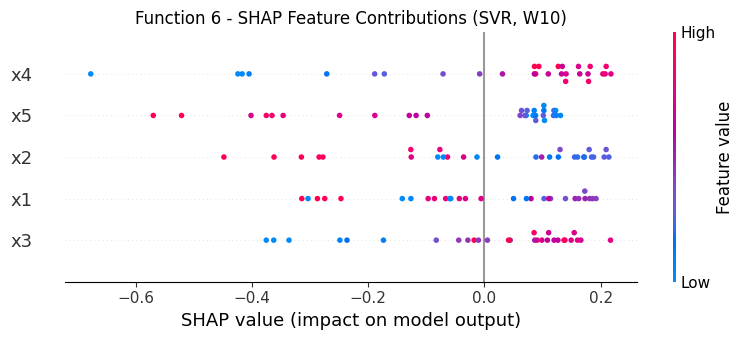

In [23]:
# =============================================================================
# FUNCTION 6 - Cake Recipe (5D)
# changes:
#   - changed SVR hyperparameters: g=0.1, C=50, e=0.001 
#      (tuned for top-point bias, not overall R2; top-5 bias drops from +0.064 to +0.015)
#   - Two-stage candidate refinement: 5000 global LHS -> top 50 -> 5000 local candidates (+-0.05 per dim)
# =============================================================================

print("\n" + "=" * 60)
print("Function 6 - Week 10")
print("=" * 60)

f6_inputs  = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_6/initial_inputs.npy')
f6_outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_6/initial_outputs.npy')

prev_queries = np.array([
    [0.201818, 0.220639, 0.476414, 0.867793, 0.023115],  # W1: -0.792
    [0.457382, 0.349799, 0.529520, 0.691032, 0.192589],  # W2: -0.362
    [0.503404, 0.328861, 0.662838, 0.995031, 0.025514],  # W3: -0.368
    [0.484266, 0.300747, 0.678836, 0.776480, 0.244496],  # W4: -0.315
    [0.341066, 0.113474, 0.924694, 0.877339, 0.257942],  # W5: -0.829
    [0.408506, 0.262542, 0.745611, 0.998966, 0.244739],  # W6: -0.563
    [0.896209, 0.283983, 0.594508, 0.806739, 0.008612],  # W7: -0.764
    [0.482908, 0.318128, 0.672147, 0.855190, 0.203478],  # W8: -0.294 (best)
    [0.527875, 0.386935, 0.580127, 0.788560, 0.032052],  # W9: -0.329
])
prev_outputs = np.array([
    -0.792246,
    -0.361637,
    -0.367626,
    -0.314817,
    -0.828981,
    -0.5633934601648388,
    -0.764298611557724,
    -0.29468304435774073,
    -0.3284779356695814,
])

all_inputs  = np.vstack([f6_inputs, prev_queries])
all_outputs = np.hstack([f6_outputs, prev_outputs])

print(f"Total observations: {all_inputs.shape[0]}, best so far: {all_outputs.max():.4f}")

# --- SVR surrogate (hyperparams tuned for top-point bias) ---
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svr = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=50, gamma=0.1, epsilon=0.001))])
svr.fit(all_inputs, all_outputs)

# --- Two-stage candidate refinement ---
space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)

# Stage 1: global LHS
np.random.seed(42)
stage1 = np.array(lhs.generate(space.dimensions, 5000))
stage1_preds = svr.predict(stage1)

# Stage 2: local refinement around top-K from stage 1
top_k = 50
top_k_idx = np.argsort(stage1_preds)[-top_k:]
top_k_points = stage1[top_k_idx]

radius = 0.05
stage2 = []
for point in top_k_points:
    local = point + np.random.uniform(-radius, radius, size=(100, 5))
    local = np.clip(local, 0, 1)
    stage2.append(local)
stage2 = np.vstack(stage2)

# Combine and score
all_candidates = np.vstack([stage1, stage2])
all_preds = svr.predict(all_candidates)
best_index = np.argmax(all_preds)
query = all_candidates[best_index]

# Report source
source = "Stage 1 (global)" if best_index < len(stage1) else "Stage 2 (refined)"

print(f"\nStage 1: {len(stage1)} global candidates")
print(f"Stage 2: {len(stage2)} local candidates ({top_k} anchors × 100 each, radius={radius})")
print(f"Total:   {len(all_candidates)} candidates")

print(f"\nWeek 10 Query (SVR): {format_query(query)}")
print(f"  Predicted value: {all_preds[best_index]:.4f}")
print(f"  Source: {source}")

# --- Interpretability: SHAP on SVR (actual surrogate) ---
np.random.seed(42)
background  = all_inputs[np.random.choice(len(all_inputs), size=20, replace=False)]
explainer   = shap.KernelExplainer(svr.predict, background)
shap_values = explainer.shap_values(all_inputs, nsamples=100)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions (SVR, W10)')
plt.tight_layout()
plt.show()


# # --- Diagonstic: SVR hyperparameter grid scored on top-point bias
# # check R2 and top-5 bais and rank by underprediction bias at top 5

# loo = LeaveOneOut()
# top5_idx = np.argsort(all_outputs)[-5:]

# gammas   = [0.05, 0.08, 0.1, 0.15, 0.2]
# Cs       = [10, 20, 50, 100]
# epsilons = [0.001, 0.005, 0.01, 0.02, 0.05]

# results = []

# for g in gammas:
#     for c in Cs:
#         for e in epsilons:
#             loo_preds = np.zeros(len(all_outputs))
#             for train_idx, test_idx in loo.split(all_inputs):
#                 pipe = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=c, gamma=g, epsilon=e))])
#                 pipe.fit(all_inputs[train_idx], all_outputs[train_idx])
#                 loo_preds[test_idx] = pipe.predict(all_inputs[test_idx].reshape(1, -1))[0]

#             errors = all_outputs - loo_preds
#             mae = np.mean(np.abs(errors))
#             ss_res = np.sum(errors**2)
#             ss_tot = np.sum((all_outputs - all_outputs.mean())**2)
#             r2 = 1 - ss_res / ss_tot

#             # top-5 bias: positive means underprediction (actual > predicted)
#             top5_bias = errors[top5_idx].mean()
#             # top-5 MAE
#             top5_mae = np.abs(errors[top5_idx]).mean()

#             results.append({
#                 'g': g, 'C': c, 'e': e,
#                 'r2': r2, 'mae': mae,
#                 'top5_bias': top5_bias, 'top5_mae': top5_mae
#             })

# # --- Stage 1: filter by R2 floor ---
# passed = [r for r in results if r['r2'] >= 0.75]
# failed = [r for r in results if r['r2'] < 0.75]

# print(f"\n{'='*70}")
# print(f"SVR Grid: {len(results)} configs tested, {len(passed)} passed R2≥0.75")
# print(f"{'='*70}")

# # --- Stage 2: rank survivors by top-5 bias (closest to 0 is best) ---
# passed.sort(key=lambda r: abs(r['top5_bias']))

# print(f"\n{'config':<22} {'R2':>6} {'MAE':>6} {'top5_bias':>10} {'top5_MAE':>9}")
# print("-" * 57)
# for r in passed[:20]:
#     label = f"g={r['g']} C={r['C']} e={r['e']}"
#     print(f"{label:<22} {r['r2']:>6.3f} {r['mae']:>6.3f} {r['top5_bias']:>+10.4f} {r['top5_mae']:>9.4f}")

# # --- Show current config for comparison ---
# print("\n--- Your w10 config for reference ---")
# w10 = [r for r in results if r['g']==0.1 and r['C']==50 and r['e']==0.001]
# if w10:
#     r = w10[0]
#     print(f"g=0.1 C=50 e=0.001    R2={r['r2']:.3f}  top5_bias={r['top5_bias']:+.4f}  top5_MAE={r['top5_mae']:.4f}")

# # --- Best config: what query does it produce? ---
# best = passed[0]
# print(f"\n--- Best config by top-5 bias: g={best['g']} C={best['C']} e={best['e']} ---")
# print(f"    R2={best['r2']:.3f}, top5_bias={best['top5_bias']:+.4f}, top5_MAE={best['top5_mae']:.4f}")

# from skopt.space import Space
# from skopt.sampler import Lhs

# space      = Space([(0.0, 1.0)] * 5)
# lhs_samp   = Lhs(criterion="maximin", iterations=100)
# np.random.seed(42)
# candidates = np.array(lhs_samp.generate(space.dimensions, 5000))

# # compare argmax queries from top 3 configs vs w9 config
# print(f"\n{'config':<22} {'pred':>7}  {'x1':>6} {'x2':>6} {'x3':>6} {'x4':>6} {'x5':>6}")
# print("-" * 64)

# configs_to_test = passed[:3]
# if w9:
#     configs_to_test.append(w9[0])

# for r in configs_to_test:
#     pipe = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=r['C'], gamma=r['g'], epsilon=r['e']))])
#     pipe.fit(all_inputs, all_outputs)
#     preds = pipe.predict(candidates)
#     best_idx = np.argmax(preds)
#     q = candidates[best_idx]
#     label = f"g={r['g']} C={r['C']} e={r['e']}"
#     print(f"{label:<22} {preds[best_idx]:>7.4f}  {q[0]:>6.3f} {q[1]:>6.3f} {q[2]:>6.3f} {q[3]:>6.3f} {q[4]:>6.3f}")

# print("\n--- Reference: top 4 actual results ---")
# for i in np.argsort(all_outputs)[-4:][::-1]:
#     q = all_inputs[i]
#     print(f"  y={all_outputs[i]:>8.4f}  x=[{q[0]:.3f}, {q[1]:.3f}, {q[2]:.3f}, {q[3]:.3f}, {q[4]:.3f}]")


# # --- Diagonstic: SVR subset analysis for Function 6

# loo = LeaveOneOut()
# svr_params = dict(kernel='rbf', C=10, gamma=0.05, epsilon=0.05)

# # --- Test 1: Full data vs top-N subsets (LOO within each subset) ---
# print("\n" + "=" * 60)
# print("Test 1: LOO accuracy by subset size")
# print("=" * 60)
# print(f"{'subset':<18} {'n':>4} {'MAE':>7} {'R2':>7}")
# print("-" * 38)

# for label, n_top in [("All 28", None), ("Top 22", 22), ("Top 18", 18), ("Top 15", 15), ("Top 12", 12), ("Top 10", 10)]:
#     if n_top is None:
#         idx = np.arange(len(all_outputs))
#     else:
#         idx = np.argsort(all_outputs)[-n_top:]
    
#     X_sub = all_inputs[idx]
#     y_sub = all_outputs[idx]
    
#     loo_preds = np.zeros(len(y_sub))
#     for train_idx, test_idx in loo.split(X_sub):
#         pipe = Pipeline([('scl', StandardScaler()), ('svr', SVR(**svr_params))])
#         pipe.fit(X_sub[train_idx], y_sub[train_idx])
#         loo_preds[test_idx] = pipe.predict(X_sub[test_idx].reshape(1, -1))[0]
    
#     errors = y_sub - loo_preds
#     mae = np.mean(np.abs(errors))
#     r2 = 1 - np.sum(errors**2) / np.sum((y_sub - y_sub.mean())**2)
#     print(f"{label:<18} {len(y_sub):>4} {mae:>7.4f} {r2:>7.4f}")

# # --- Test 2: LOO predictions vs actuals at top 8 points (full model) ---
# print("\n" + "=" * 60)
# print("Test 2: LOO residuals at best observations (full 28-point SVR)")
# print("=" * 60)

# loo_preds_full = np.zeros(len(all_outputs))
# for train_idx, test_idx in loo.split(all_inputs):
#     pipe = Pipeline([('scl', StandardScaler()), ('svr', SVR(**svr_params))])
#     pipe.fit(all_inputs[train_idx], all_outputs[train_idx])
#     loo_preds_full[test_idx] = pipe.predict(all_inputs[test_idx].reshape(1, -1))[0]

# top8_idx = np.argsort(all_outputs)[-8:]
# print(f"{'rank':<6} {'actual':>8} {'predicted':>10} {'error':>8} {'bias':>6}")
# print("-" * 40)
# for rank, i in enumerate(reversed(top8_idx)):
#     err = all_outputs[i] - loo_preds_full[i]
#     bias = "over" if err < 0 else "under"
#     print(f"{rank+1:<6} {all_outputs[i]:>8.4f} {loo_preds_full[i]:>10.4f} {err:>+8.4f} {bias:>6}")

# # --- Test 3: Argmax comparison across subsets ---
# print("\n" + "=" * 60)
# print("Test 3: SVR argmax query by subset (same candidate pool)")
# print("=" * 60)

# from skopt.space import Space
# from skopt.sampler import Lhs

# space      = Space([(0.0, 1.0)] * 5)
# lhs        = Lhs(criterion="maximin", iterations=100)
# np.random.seed(42)
# candidates = np.array(lhs.generate(space.dimensions, 5000))

# print(f"{'subset':<18} {'pred':>7}  {'x1':>6} {'x2':>6} {'x3':>6} {'x4':>6} {'x5':>6}")
# print("-" * 62)

# for label, n_top in [("All 28", None), ("Top 18", 18), ("Top 15", 15), ("Top 12", 12), ("Top 10", 10)]:
#     if n_top is None:
#         idx = np.arange(len(all_outputs))
#     else:
#         idx = np.argsort(all_outputs)[-n_top:]
    
#     X_sub = all_inputs[idx]
#     y_sub = all_outputs[idx]
    
#     pipe = Pipeline([('scl', StandardScaler()), ('svr', SVR(**svr_params))])
#     pipe.fit(X_sub, y_sub)
#     preds = pipe.predict(candidates)
#     best = np.argmax(preds)
#     q = candidates[best]
#     print(f"{label:<18} {preds[best]:>7.4f}  {q[0]:>6.3f} {q[1]:>6.3f} {q[2]:>6.3f} {q[3]:>6.3f} {q[4]:>6.3f}")

# # --- Reference: best query points ---
# print("\n--- Reference: top 4 results ---")
# for i in np.argsort(all_outputs)[-4:][::-1]:
#     q = all_inputs[i]
#     print(f"  y={all_outputs[i]:>8.4f}  x=[{q[0]:.3f}, {q[1]:.3f}, {q[2]:.3f}, {q[3]:.3f}, {q[4]:.3f}]")

# Function 7 - week 10


Function 7 - Week 10
Total points: 39, best: 2.6016

Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.664
  HP2: 0.137
  HP3: 0.030
  HP4: 0.026
  HP5: 0.051
  HP6: 0.091

Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 13
Output range in subset: 0.008 to 2.602

Filtered RF importance:
  HP1: 0.114  (was 0.664 in full dataset) ***
  HP2: 0.473  (was 0.137 in full dataset) ***
  HP3: 0.063  (was 0.030 in full dataset) 
  HP4: 0.096  (was 0.026 in full dataset) 
  HP5: 0.133  (was 0.051 in full dataset) 
  HP6: 0.121  (was 0.091 in full dataset) 

Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.664        1.069      0.205
  HP2           0.137        0.122      0.032
  HP3           0.030        0.017      0.004
  HP4           0.026        0.014      0.005
  HP5           0.051        0.039      0.007
  HP6           0.091        0.068      0.019

Permutation vs 

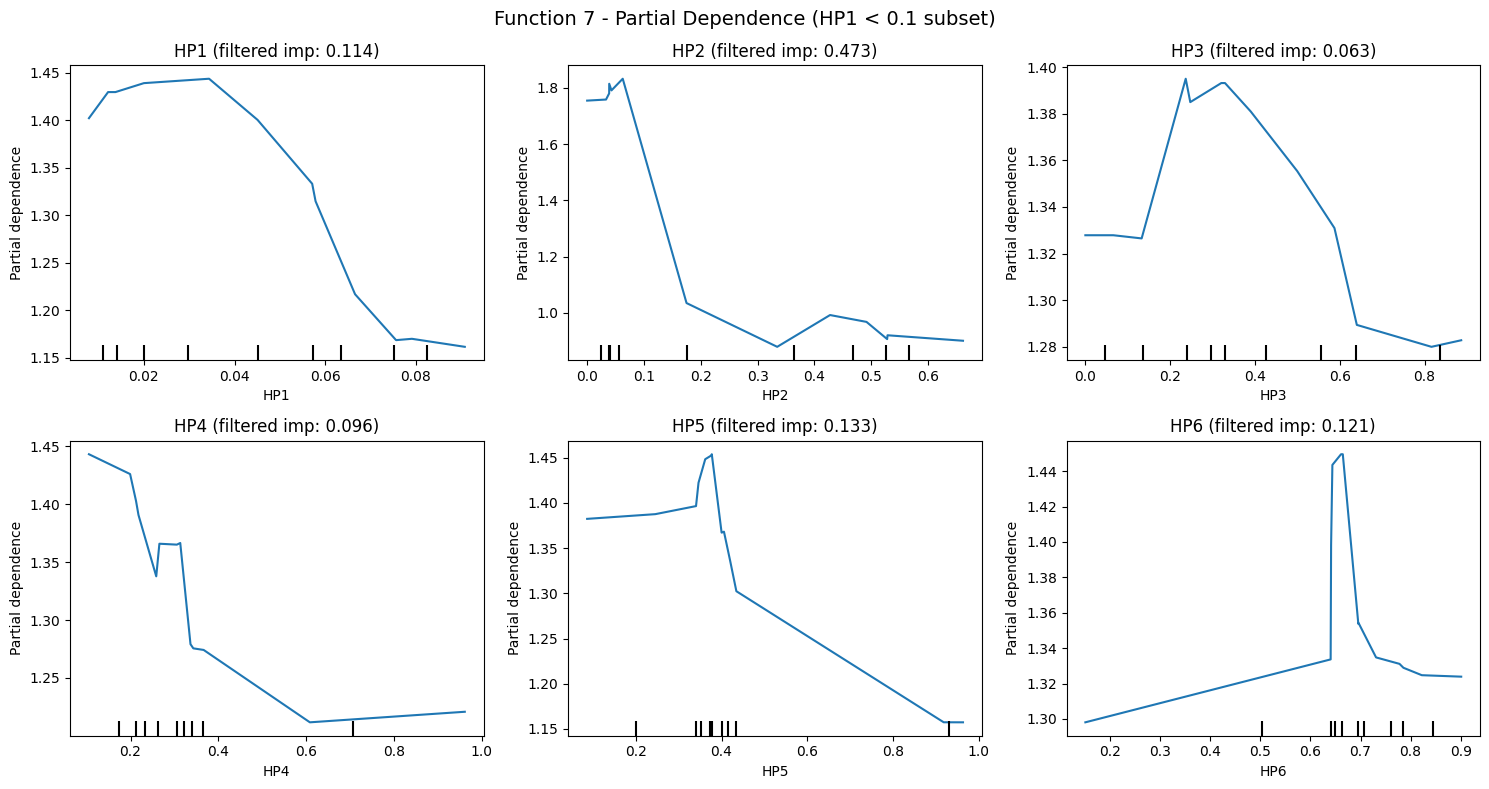

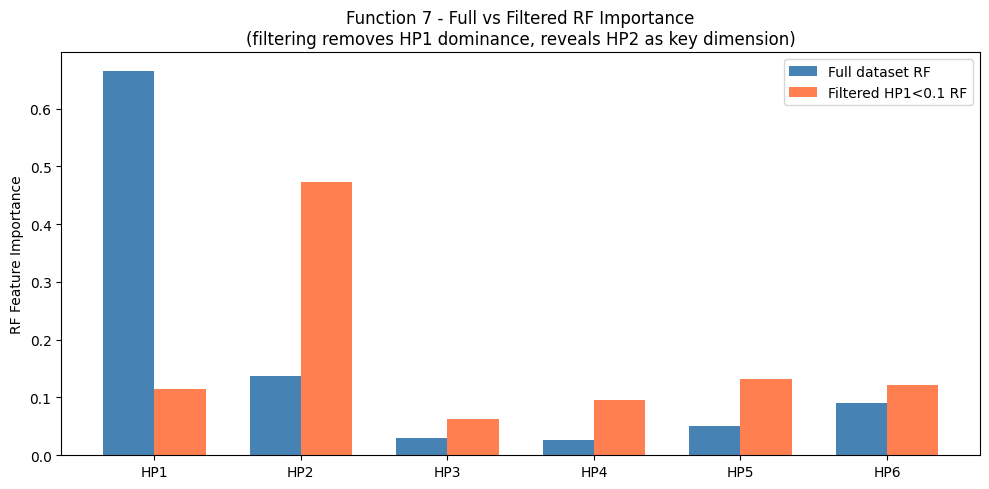

In [12]:
# =============================================================================
# FUNCTION 7 - ML Hyperparameters (6D)
# changes: 
#   - changed filter threshold back to 0.1
#   - switched GP output transform from log1p to sqrt
#   - switched acquisition function from UCB to EI
# =============================================================================

print("\n" + "=" * 60)
print("Function 7 - Week 10")
print("=" * 60)

f7_inputs  = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_7/initial_inputs.npy')
f7_outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_7/initial_outputs.npy')

prev_queries = np.array([
    [0.045091, 0.528666, 0.329265, 0.105350, 0.434671, 0.641164],  # W1: 1.051
    [0.034389, 0.427542, 0.236649, 0.342956, 0.405706, 0.695527],  # W2: 1.653
    [0.020000, 0.062635, 0.587368, 0.313225, 0.362008, 0.664539],  # W3: 2.602 (best)
    [0.012096, 0.033240, 0.640160, 0.336533, 0.245422, 0.901043],  # W4: 1.509
    [0.007872, 0.174935, 0.499616, 0.265730, 0.340533, 0.150339],  # W5: 0.383
    [0.020000, 0.000000, 0.000000, 0.212520, 0.346351, 0.696182],  # W6: 1.790
    [0.079160, 0.042812, 0.886277, 0.366485, 0.400229, 0.661016],  # W7: 1.429
    [0.057146, 0.038834, 0.320530, 0.305527, 0.377308, 0.643734],  # W8: 2.556
    [0.013721, 0.038746, 0.389878, 0.199046, 0.377306, 0.785650],  # W9: 2.106
])
prev_outputs = np.array([
    1.0510006614196026, 
    1.6531363312716738, 
    2.6016443512251484,
    1.5087286481808686, 
    0.3832671270292543, 
    1.789927976010441,
    1.428502150382287,
    2.5567422716339334,
    2.106393447839423,
])

all_inputs  = np.vstack([f7_inputs, prev_queries])
all_outputs = np.hstack([f7_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")
        
feature_names = [f"HP{i+1}" for i in range(6)]

# --- Step 1a: Full-dataset Random Forest
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs, all_outputs)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")

# --- Step 1b: Filtered RF (HP1 < threshold subset)
# returned to 0.1 threshold
hp1_threshold = 0.1
print(f"\nStep 1b: Filtered Random Forest + SHAP (HP1 < {hp1_threshold} subset)")
hp1_mask = all_inputs[:, 0] < hp1_threshold
filtered_inputs  = all_inputs[hp1_mask]
filtered_outputs = all_outputs[hp1_mask]

print(f"Points with HP1 < {hp1_threshold}: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")

# Permutation importance validation (both RFs)
from sklearn.inspection import permutation_importance

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs, all_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")

# SHAP on filtered RF (diagnostic)
explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")

# --- Step 2: Sequential RF filtering 
print("\nStep 2: Sequential RF Filtering")

np.random.seed(42)
n_initial = 100000
candidates = np.random.uniform(0, 1, size=(n_initial, 6))

# Stage 1: full RF filters to top 10,000
full_preds = rf_full.predict(candidates)
top10k_idx = np.argsort(full_preds)[-10000:]
stage1 = candidates[top10k_idx]

print(f"\nStage 1: Full RF {n_initial} -> 10,000 candidates")
print(f"  Predicted output range: [{full_preds[top10k_idx].min():.3f}, {full_preds[top10k_idx].max():.3f}]")

# Stage 2: filtered RF filters to top 1,000
filt_preds = rf_filtered.predict(stage1)
top1k_idx = np.argsort(filt_preds)[-1000:]
stage2 = stage1[top1k_idx]
stage2_preds = filt_preds[top1k_idx]

print(f"Stage 2: Filtered RF 10,000 -> 1,000 candidates")
print(f"  Predicted output range: [{stage2_preds.min():.3f}, {stage2_preds.max():.3f}]")
print(f"\n  Feature ranges in final candidate pool:")
for i, name in enumerate(feature_names):
    print(f"    {name}: [{stage2[:, i].min():.3f}, {stage2[:, i].max():.3f}]  mean={stage2[:, i].mean():.3f}")

# --- Step 3: GP with EI on filtered candidates
print("\nStep 3: GP with EI (on 1,000 RF-filtered candidates)")

kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
) + ConstantKernel(0.1, (0.01, 5.0)) * DotProduct(sigma_0=0.1, sigma_0_bounds=(0.01, 1.0))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp.fit(all_inputs, np.sqrt(all_outputs))

mu, sigma = gp.predict(stage2, return_std=True)

# EI in sqrt space
best_so_far = np.sqrt(all_outputs.max())
from scipy.stats import norm
xi = 0.01
z = (mu - best_so_far - xi) / (sigma + 1e-10)
ei = (mu - best_so_far - xi) * norm.cdf(z) + sigma * norm.pdf(z)
ei[sigma < 1e-10] = 0.0

best_idx = np.argmax(ei)
best_candidate = stage2[best_idx]

predicted_mean, predicted_std = gp.predict(best_candidate.reshape(1, -1), return_std=True)
predicted_y = predicted_mean[0] ** 2

print(f"\nFitted kernel: {gp.kernel_}")
print(f"\nWeek 10 Query: {format_query(best_candidate)}")
print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (sqrt scale std) : {predicted_std[0]:.4f}")
print(f"EI score (sqrt scale)           : {ei[best_idx]:.6f}")

# --- Interpretability: Partial dependence on filtered RF ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()


# # -- Diagnostic
# from sklearn.metrics import r2_score
# from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel
# import copy

# top4_idx = np.argsort(all_outputs)[-4:]

# def apply_transform(y, t):
#     if t == "log1p": return np.log1p(y)
#     if t == "sqrt": return np.sqrt(y)
#     return y.copy()

# def invert_transform(y, t):
#     if t == "log1p": return np.expm1(y)
#     if t == "sqrt": return y ** 2
#     return y

# configs = {}
# for transform in ["log1p", "none", "sqrt"]:
#     for kernel_name, kernel in {
#         "Matern 2.5": ConstantKernel(1.0, (0.01, 10.0)) * Matern(
#             length_scale=[0.3]*6, length_scale_bounds=(0.05, 5.0), nu=2.5),
#         "RatQuad": ConstantKernel(1.0, (0.01, 10.0)) * RationalQuadratic(
#             length_scale=0.3, alpha=1.0, 
#             length_scale_bounds=(0.05, 5.0), alpha_bounds=(0.01, 100.0)),
#     }.items():
#         configs[f"{kernel_name}, {transform}"] = {
#             "kernel": kernel,
#             "transform": transform,
#         }

# print("GP Structural Comparison: LOO R2 on top-4 points")
# print("=" * 85)

# for config_name, cfg in configs.items():
#     actuals = []
#     predictions = []
    
#     for idx in top4_idx:
#         loo_inputs = np.delete(all_inputs, idx, axis=0)
#         loo_outputs = np.delete(all_outputs, idx, axis=0)
        
#         kernel = copy.deepcopy(cfg["kernel"])
#         gp_loo = GaussianProcessRegressor(
#             kernel=kernel,
#             n_restarts_optimizer=20,
#             normalize_y=True,
#             alpha=1e-10,
#         )
#         y_train = apply_transform(loo_outputs, cfg["transform"])
#         gp_loo.fit(loo_inputs, y_train)
        
#         mu, _ = gp_loo.predict(all_inputs[idx].reshape(1, -1), return_std=True)
#         pred = invert_transform(mu[0], cfg["transform"])
#         predictions.append(pred)
#         actuals.append(all_outputs[idx])
    
#     r2 = r2_score(actuals, predictions)
#     errors = np.array(predictions) - np.array(actuals)
    
#     print(f"\n  {config_name}:")
#     print(f"    Top-4 R2 = {r2:.3f}  |  Mean err = {errors.mean():+.3f}  |  Max |err| = {np.abs(errors).max():.3f}")
#     for i, idx in enumerate(reversed(top4_idx)):
#         source = "initial" if idx < len(f7_inputs) else f"W{idx - len(f7_inputs) + 1}"
#         print(f"      {source}: pred {predictions[-(i+1)]:.3f} vs actual {actuals[-(i+1)]:.3f} ({errors[-(i+1)]:+.3f})")


# print("GP Kernel Comparison: LOO R2 on top-4 points")
# print("=" * 80)

# top4_idx = np.argsort(all_outputs)[-4:]

# for config_name, cfg in kernel_configs.items():
#     actuals = []
#     predictions = []
    
#     for idx in top4_idx:
#         loo_inputs = np.delete(all_inputs, idx, axis=0)
#         loo_outputs = np.delete(all_outputs, idx, axis=0)
        
#         if cfg.get("ls_init") is None:
#             # ARD-style: init length scales from per-feature std of training data
#             ls_init = list(loo_inputs.std(axis=0))
#         else:
#             ls_init = [cfg.get("ls_init", 0.3)] * 6
        
#         kernel = ConstantKernel(1.0, cfg["constant_bounds"]) * Matern(
#             length_scale=ls_init,
#             length_scale_bounds=cfg["length_scale_bounds"],
#             nu=cfg["nu"],
#         )
#         gp_loo = GaussianProcessRegressor(
#             kernel=kernel,
#             n_restarts_optimizer=20,
#             normalize_y=True,
#         )
#         gp_loo.fit(loo_inputs, np.log1p(loo_outputs))
        
#         mu_log, _ = gp_loo.predict(all_inputs[idx].reshape(1, -1), return_std=True)
#         predictions.append(np.expm1(mu_log[0]))
#         actuals.append(all_outputs[idx])
    
#     r2 = r2_score(actuals, predictions)
#     errors = np.array(predictions) - np.array(actuals)
    
#     print(f"\n  {config_name}:")
#     print(f"    Top-4 R2 = {r2:.3f}  |  Mean err = {errors.mean():+.3f}  |  Max |err| = {np.abs(errors).max():.3f}")
#     for i, idx in enumerate(reversed(top4_idx)):
#         source = "initial" if idx < len(f7_inputs) else f"W{idx - len(f7_inputs) + 1}"
#         print(f"      {source}: pred {predictions[-(i+1)]:.3f} vs actual {actuals[-(i+1)]:.3f} ({errors[-(i+1)]:+.3f})")

# Function 8 - week 10


Function 8 - Week 10
Total points: 49, best: 9.6741

LOO Calibration (dropout=0.25):
  mean |error|:        0.2127
  std  |error|:        0.1815
  max  |error|:        0.7006
  mean sigma (LOO):    0.2070
  ratio (error/sigma): 1.027  (1.0 = perfect calibration)
  kappa (adaptive):    1.75

Top-k LOO Calibration (output > 9.0):
  n points:            14
  mean |error|:        0.1360
  std  |error|:        0.1304
  max  |error|:        0.4989
  mean sigma:          0.2115
  ratio (error/sigma): 0.643
  global ratio was:    1.027

  Per-point breakdown (top-k):
    point 14: y=9.5985, |err|=0.0768, sigma=0.2162, ratio=0.355
    point 19: y=9.0131, |err|=0.2434, sigma=0.1712, ratio=1.422
    point 22: y=9.1416, |err|=0.2179, sigma=0.1307, ratio=1.667
    point 26: y=9.3443, |err|=0.4989, sigma=0.1455, ratio=3.429
    point 39: y=9.1830, |err|=0.0361, sigma=0.1744, ratio=0.207
    point 40: y=9.6724, |err|=0.0490, sigma=0.2316, ratio=0.211
    point 41: y=9.6264, |err|=0.1045, sigma=0.206

  0%|          | 0/49 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_30410/3006196442.py:277: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


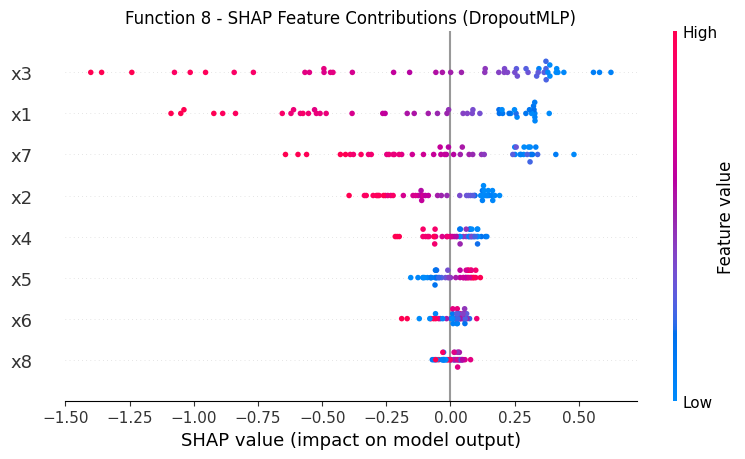


SHAP-derived importance (normalised):
  x1: 0.836
  x2: 0.348
  x3: 1.000
  x4: 0.168
  x5: 0.146
  x6: 0.104
  x7: 0.550
  x8: 0.068

mu   range: 4.320 to 9.673
sigma range: 0.057 to 0.760
kappa*sigma range: 0.099 to 1.327

Week 10 Query: 0.068646-0.267399-0.019682-0.160065-0.776599-0.459921-0.106417-0.402908
MC mu: 9.6735, sigma: 0.1572
UCB:   9.9138


In [24]:
# =============================================================================
# FUNCTION 8 - 8D Black-Box
# changes:
#   - MLU activation function changed from ReLU to SiLU (smooth gradients to better model curvature near optimum)
#   - hidden units from 24 to 48 (increased capacity to capture finer local structure)
#   - weighted MSE loss (10× for output > 9.5, 5× for > 9.0 -- to focus model accuracy at the top)
#   - candidate pool: from constrained refinement to global LHS 50k (removes prior assumptions)
#   - Note: kept kappa at 1.7, because the same query even with a lower kappa at 1.2
# =============================================================================

print("\n" + "=" * 60)
print("Function 8 - Week 10")
print("=" * 60)

f8_inputs  = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_8/initial_inputs.npy')
f8_outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_8/initial_outputs.npy')

prev_queries = np.array([
    [0.182943, 0.000000, 0.000000, 0.000000, 0.999999, 0.127124, 0.092403, 0.000000],  # W1: 9.672
    [0.022695, 0.000000, 0.274348, 0.000000, 0.999999, 0.127124, 0.028034, 0.000000],  # W2: 9.626
    [0.005086, 0.000000, 0.048567, 0.000000, 0.999999, 0.998962, 0.018674, 0.000000],  # W3: 9.546
    [0.000000, 0.000000, 0.012582, 0.000000, 0.999999, 0.000000, 0.066411, 0.000000],  # W4: 9.552
    [0.143046, 0.934478, 0.256793, 0.378273, 0.985471, 0.743394, 0.090143, 0.014829],  # W5: 9.146
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],  # W6: 9.620
    [0.000000, 0.000000, 0.000000, 0.120009, 0.144817, 0.385066, 0.000000, 0.986589],  # W7: 9.583
    [0.134058, 0.010517, 0.000000, 0.000705, 0.991616, 0.110483, 0.084702, 0.012878],  # W8: 9.674 (best)
    [0.167672, 0.021651, 0.000000, 0.000669, 0.988603, 0.107425, 0.054024, 0.014735],  # W9: 9.652
])
prev_outputs = np.array([
    9.6723503773075, 
    9.6263579169495, 
    9.5463675507445,
    9.5519471979855, 
    9.1457303782294, 
    9.6199985919071,
    9.5831132283264,
    9.6740952800446,
    9.652595613866,
])

all_inputs  = np.vstack([f8_inputs, prev_queries])
all_outputs = np.hstack([f8_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")

# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs)
Y_sc = scaler_y.fit_transform(all_outputs.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=24, dropout=0.25 (increased from 0.2 for better calibration)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

# LOO CV with dropout=0.25
loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs)):
    X_train_loo = np.delete(all_inputs, i, axis=0)
    y_train_loo = np.delete(all_outputs, i)
    X_test_loo  = all_inputs[i:i+1]
    y_test_loo  = all_outputs[i]

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

# Adaptive kappa: base * calibration ratio 
kappa_base = 1.7
cal_ratio  = loo_errors.mean() / loo_sigmas.mean()
kappa      = kappa_base * cal_ratio

print(f"\nLOO Calibration (dropout=0.25):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio:.3f}  (1.0 = perfect calibration)")
print(f"  kappa (adaptive):    {kappa:.2f}")


# --- Top-k LOO calibration analysis ---
top_k_threshold = 9.0
top_k_mask = all_outputs > top_k_threshold
top_k_indices = np.where(top_k_mask)[0]

top_k_errors = loo_errors[top_k_mask]
top_k_sigmas = loo_sigmas[top_k_mask]

top_k_cal_ratio = top_k_errors.mean() / top_k_sigmas.mean()

print(f"\nTop-k LOO Calibration (output > {top_k_threshold}):")
print(f"  n points:            {len(top_k_indices)}")
print(f"  mean |error|:        {top_k_errors.mean():.4f}")
print(f"  std  |error|:        {top_k_errors.std():.4f}")
print(f"  max  |error|:        {top_k_errors.max():.4f}")
print(f"  mean sigma:          {top_k_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_ratio:.3f}")
print(f"  global ratio was:    {cal_ratio:.3f}")



# Per-point breakdown for the top-k
print(f"\n  Per-point breakdown (top-k):")
for idx in top_k_indices:
    print(f"    point {idx:2d}: y={all_outputs[idx]:.4f}, "
          f"|err|={loo_errors[idx]:.4f}, sigma={loo_sigmas[idx]:.4f}, "
          f"ratio={loo_errors[idx]/loo_sigmas[idx]:.3f}")

# --- High-error initial points: where are they? ---
high_error_initial = [14, 22, 26, 39]
print("\nHigh-error initial points (output > 9.0):")
for idx in high_error_initial:
    print(f"  point {idx}: {np.array2string(all_inputs[idx], precision=3, suppress_small=True)}"
          f"  y={all_outputs[idx]:.4f}  |err|={loo_errors[idx]:.4f}")

# Compare to best query (W8)
print(f"\n  W8 (best): {np.array2string(all_inputs[47], precision=3, suppress_small=True)}"
      f"  y={all_outputs[47]:.4f}")


# --- train final model (weighted loss, increased capacity) ---
# Weight: high-scoring points matter more
weights = np.ones(len(all_outputs))
weights[all_outputs > 9.0] = 5.0
weights[all_outputs > 9.5] = 10.0
weight_tensor = torch.tensor(weights, dtype=torch.float32)

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(1500):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = (weight_tensor * (pred.squeeze() - Y_tensor.squeeze())**2).mean()
    loss.backward()
    optimiser.step()

print(f"Training loss (final, weighted): {loss.item():.6f}")

# --- Weighted LOO for comparison ---
loo_errors_w = []
loo_sigmas_w = []

for i in range(len(all_outputs)):
    X_train_loo = np.delete(all_inputs, i, axis=0)
    y_train_loo = np.delete(all_outputs, i)
    X_test_loo  = all_inputs[i:i+1]
    y_test_loo  = all_outputs[i]

    w_loo = np.ones(len(y_train_loo))
    w_loo[y_train_loo > 9.0] = 5.0
    w_loo[y_train_loo > 9.5] = 10.0
    w_loo_tensor = torch.tensor(w_loo, dtype=torch.float32)

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1500):
        optimiser_loo.zero_grad()
        pred_loo = model_loo(X_tr_tensor)
        loss_loo = (w_loo_tensor * (pred_loo.squeeze() - Y_tr_tensor.squeeze())**2).mean()
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors_w.append(abs(mu_loo - y_test_loo))
    loo_sigmas_w.append(sigma_loo)

loo_errors_w = np.array(loo_errors_w)
loo_sigmas_w = np.array(loo_sigmas_w)

cal_ratio_w = loo_errors_w.mean() / loo_sigmas_w.mean()
kappa_w     = kappa_base * cal_ratio_w

print(f"\nWeighted LOO Calibration (hidden=48):")
print(f"  mean |error|:        {loo_errors_w.mean():.4f}")
print(f"  mean sigma:          {loo_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio_w:.3f}")
print(f"  kappa (adaptive):    {kappa_w:.2f}")

# Top-k breakdown (weighted model)
top_k_mask_w = all_outputs > 9.0
top_k_errors_w = loo_errors_w[top_k_mask_w]
top_k_sigmas_w = loo_sigmas_w[top_k_mask_w]
top_k_cal_w    = top_k_errors_w.mean() / top_k_sigmas_w.mean()

print(f"\nWeighted Top-k LOO (output > 9.0):")
print(f"  mean |error|:        {top_k_errors_w.mean():.4f}")
print(f"  mean sigma:          {top_k_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_w:.3f}")
print(f"  previous top-k ratio was: 0.683")

print(f"\n  Per-point breakdown (top-k, weighted):")
top_k_indices_w = np.where(top_k_mask_w)[0]
for idx in top_k_indices_w:
    print(f"    point {idx:2d}: y={all_outputs[idx]:.4f}, "
          f"|err|={loo_errors_w[idx]:.4f}, sigma={loo_sigmas_w[idx]:.4f}, "
          f"ratio={loo_errors_w[idx]/loo_sigmas_w[idx]:.3f}")

# --- SHAP on the DropoutMLP ---
model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP)')
plt.tight_layout()
plt.show()

model.train()  # back to train mode for MC dropout

# --- SHAP importance for noise scaling ---
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")

# ------ trying evenly spaced pool
sampler = LatinHypercube(d=8, seed=42)
pool = sampler.random(n=50000)

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=100)

mu    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb      = mu + kappa_w * sigma
best_idx = np.argmax(ucb)
query    = pool[best_idx]

print(f"\nmu   range: {mu.min():.3f} to {mu.max():.3f}")
print(f"sigma range: {sigma.min():.3f} to {sigma.max():.3f}")
print(f"kappa*sigma range: {(kappa*sigma).min():.3f} to {(kappa*sigma).max():.3f}")

print(f"\nWeek 10 Query: {format_query(query)}")
print(f"MC mu: {mu[best_idx]:.4f}, sigma: {sigma[best_idx]:.4f}")
print(f"UCB:   {ucb[best_idx]:.4f}")